# deltas_v7

This notebook extends `deltas_v6` with an explicit query-specific history representation for the addition head.

Main goals:

- keep the data flow explicit from snapshot -> triples -> deltas -> candidates -> labels
- add a sparse history cache that computes explicit history features only for scored proposals
- leave the proposer, encoder, and deletion head mostly unchanged so the new logic is easy to isolate
- add many inline comments and assertions so silent bugs fail loudly

## Explicit History System

This notebook adds an explicit query-specific history vector `phi(u, r, v, t)` that is used **only by the addition head**.
The proposer, encoder, and deletion head remain structurally the same.

### Implemented `phi(u, r, v, t)`

For recent window `W = HISTORY_RECENT_WINDOW`, candidate triple `(u, r, v)`, and timestep `t`, the implemented feature vector is:

`phi(u, r, v, t) in R^18`

Pair-level features:

- `pair_ever_seen = 1[(u, v) has appeared before]`
- `pair_recency = 1 / (1 + (t - last_seen_pair(u, v)))`, or `0` if unseen
- `pair_total_count_log = log(1 + total_pair_count(u, v))`
- `pair_recent_count_log = log(1 + recent_pair_count_W(u, v, t))`
- `pair_last_streak_log = log(1 + last_pair_streak(u, v))`

Triple-level features:

- `triple_ever_seen = 1[(u, r, v) has appeared before]`
- `triple_recency = 1 / (1 + (t - last_seen_triple(u, r, v)))`, or `0` if unseen
- `triple_total_count_log = log(1 + total_triple_count(u, r, v))`
- `triple_recent_count_log = log(1 + recent_triple_count_W(u, r, v, t))`
- `triple_last_streak_log = log(1 + last_triple_streak(u, r, v))`

Node-level features:

- `src_activity_total_log = log(1 + total_incident_triples(u))`
- `dst_activity_total_log = log(1 + total_incident_triples(v))`
- `src_activity_recent_log = log(1 + recent_incident_triples_W(u, t))`
- `dst_activity_recent_log = log(1 + recent_incident_triples_W(v, t))`
- `src_rel_out_count_log = log(1 + total_outgoing_relation_count(u, r))`
- `dst_rel_in_count_log = log(1 + total_incoming_relation_count(v, r))`

Structural features:

- `common_neighbors_log = log(1 + |N_t(u) intersect N_t(v)|)` using the current snapshot's undirected neighborhoods
- `recent_two_hop_log = log(1 + |RecentOut_W(u, t) intersect RecentIn_W(v, t)|)`

All count-like features use `log(1 + x)` compression. Recency uses the bounded transform `1 / (1 + delta_t)`.

### Sparse caches

The history system uses only sparse observed-event caches; it does **not** build dense `num_nodes x num_nodes` tensors.

- pair caches: `pair_last_seen`, `pair_total_count`, `pair_recent_times`, `pair_last_streak`
- triple caches: `triple_last_seen`, `triple_total_count`, `triple_recent_times`, `triple_last_streak`
- node caches: `node_total_activity`, `node_recent_times`, `node_out_rel_count`, `node_in_rel_count`
- structural caches: `current_neighbors`, `recent_out_neighbors`, `recent_in_neighbors`

Each timestep update touches only the current snapshot's edges, so the cache update cost is `O(|E_t|)`.
Feature extraction is then `O(B)` sparse lookup work for `B` scored proposals, plus small set intersections for the structural terms.

### Update pseudocode

```text
for timestep t:
    current_pair_set = unique ordered pairs in snapshot_t
    current_triple_set = unique triples in snapshot_t
    update pair last-seen / counts / recent queues / streaks
    update triple last-seen / counts / recent queues / streaks
    update node activity counters and node-relation counters
    rebuild current neighbors and refresh recent out/in neighbor maps
```

### Extraction pseudocode

```text
given candidate batch C = [(u_i, r_i, v_i)]_{i=1..B}:
    for each candidate:
        lookup sparse pair statistics for (u_i, v_i)
        lookup sparse triple statistics for (u_i, r_i, v_i)
        lookup sparse node statistics for u_i, v_i, and relation r_i
        compute current common-neighbor and recent two-hop counts
        append phi(u_i, r_i, v_i, t)
    stack rows into Phi in R^{B x 18}
```

### Scoring input and shapes

Let batch size be `B`, relation width be `D_r = RELATION_DIM`, and history width be `D_phi = 18`.

- `src_proj in R^{B x D_r}` from `[h_u^G ; h_u^L]`
- `rel_emb in R^{B x D_r}` from `e_r`
- `dst_proj in R^{B x D_r}` from `[h_v^G ; h_v^L]`
- `src_proj * dst_proj in R^{B x D_r}`
- `|src_proj - dst_proj| in R^{B x D_r}`
- `phi_proj in R^{B x D_r}` from a small history projection MLP
- `phi_raw in R^{B x D_phi}`

The final addition-scoring input is:

`concat(src_proj, rel_emb, dst_proj, src_proj * dst_proj, |src_proj - dst_proj|, phi_proj, phi_raw)`

So the MLP input shape is `R^{B x (6 * D_r + D_phi)}`. With the default `D_r = 64`, this is `R^{B x 402}`.

### Division of labor with the LSTM

- the LSTM captures **latent temporal context** that is hard to summarize manually
- `phi(u, r, v, t)` captures **explicit sparse facts** such as recency, counts, streaks, and local graph structure
- the scorer receives both, so the model can use explicit history when it matters and still rely on the LSTM for richer temporal context
- redundancy is limited because `phi` is narrow, sparse, and interpretable, while the LSTM remains the high-capacity latent channel

### Minimal working version in this notebook

The implementation here is the intended small-but-strong version:

- explicit `phi(u, r, v, t)` is only computed for scored addition candidates
- sparse caches are updated once per timestep in chronological order
- the deletion head is left unchanged
- the addition head is the only place where explicit history enters the model

### Training note

The printed precision, recall, and F1 below are still **oracle top-n diagnostics**.

- for deletions, validation selects exactly as many predicted deletions as there are true deletions
- for additions, validation selects exactly as many predicted additions as there are true additions

Those metrics are useful for scorer debugging, but they are not rollout metrics.
To keep proposer quality visible, the notebook reports `add_proposal_recall` separately.

In [1]:
# Import the standard-library containers used throughout the notebook.
from collections import Counter, defaultdict, deque

# Import a convenient path helper for locating the dataset JSON file.
from pathlib import Path

# Import Python's built-in random module for candidate sampling.
import random

# Import colorsys so similarity-based HSV colors can be converted into RGB hex.
import colorsys

# Import a lightweight timer so epoch runtimes are easy to inspect.
import time

# Import typing helpers to make function signatures clearer.
from typing import Dict, Iterable, List, Optional, Sequence, Set, Tuple

# Import plotting so we can visualize learning curves and rollouts.
import matplotlib.pyplot as plt

# Import NetworkX for subgraph visualization after training.
import networkx as nx

# Import NumPy because it is still useful for fixed seeding and layout helpers.
import numpy as np

# Import PyTorch itself.
import torch

# Import the neural-network module base classes.
import torch.nn as nn

# Import PyTorch functional helpers such as BCE and normalization.
import torch.nn.functional as F

# Import the notebook display helper used for inline figures.
from IPython.display import display as ipy_display

# Import the PyG message-passing base class.
from torch_geometric.nn import MessagePassing

# Import segment-wise softmax for attention normalization.
from torch_geometric.utils import softmax

# Add the data-exploration folder to the import path so the synthetic dataset class is visible.
import sys
sys.path.append("../data_exploration")

# Import the exact synthetic dataset class that deltas_v4 used.
from synthetic_dataset_class import SyntheticTemporalGraphDataset

# Fix the global random seed so debugging runs are easier to reproduce.
SEED = 7

# Seed Python's random module.
random.seed(SEED)

# Seed NumPy.
np.random.seed(SEED)

# Seed PyTorch on CPU.
torch.manual_seed(SEED)

# Seed PyTorch on every CUDA device when CUDA is available.
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Pick the training device once and reuse it everywhere else.
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Point to the same synthetic dataset family used in deltas_v4.
DATASET_PATH = Path("../data_exploration/synthetic_data/2ent_5rel.json")

# Load the dataset from disk.
dataset = SyntheticTemporalGraphDataset.from_json(DATASET_PATH)

# Choose a chronological validation window that is safe for small synthetic datasets.
VAL_STEPS = min(10, max(1, len(dataset) // 5))

# Choose model width for node states.
HIDDEN_DIM = 128

# Choose relation-embedding width inside the scorer and GNN.
RELATION_DIM = 64

# Choose the number of stacked message-passing layers.
NUM_GNN_LAYERS = 1

# Choose the number of attention heads.
NUM_HEADS = 4

# Choose the dropout rate used inside the GNN.
DROPOUT = 0.1

# Choose the optimizer learning rate.
LEARNING_RATE = 1e-3

# Choose a small amount of weight decay for stability.
WEIGHT_DECAY = 1e-5

# Choose the number of training epochs.
EPOCHS = 100

# Choose how many positive examples per head we try to keep in each training step.
TRAIN_SAMPLE_SIZE = 128

# Choose how many raw addition proposals we ask the proposer for before label construction.
PROPOSAL_TARGET_COUNT = 256

# Choose the truncated-BPTT window length.
BPTT_STEPS = 8

# Choose how many past edge sets the proposer can look back at.
HISTORY_LEN = 5

# Choose how many timesteps count as "recent" inside the explicit history features.
HISTORY_RECENT_WINDOW = 8

# Choose the number of random-negative additions per positive addition.
NEGATIVES_PER_POSITIVE = 1

# Print the key environment details.
print(f"device: {DEVICE}")
print(f"dataset path: {DATASET_PATH}")
print(f"num timesteps: {len(dataset)}")
print(f"x_global shape: {tuple(dataset.x_global.shape)}")
print(f"num relations: {len(dataset.id_to_rel)}")
print(f"relations: {dataset.id_to_rel}")

# Peek at one snapshot so field names and shapes are obvious before training starts.
example_snapshot = dataset[min(1, len(dataset) - 1)]
print(f"example edge_index shape: {tuple(example_snapshot.edge_index.shape)}")
print(f"example edge_type shape: {tuple(example_snapshot.edge_type.shape)}")
print(f"example edge_relative_time shape: {tuple(example_snapshot.edge_relative_time.shape)}")

C:\Users\jaden\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device: cuda
dataset path: ..\data_exploration\synthetic_data\2ent_5rel.json
num timesteps: 250
x_global shape: (28, 8)
num relations: 5
relations: {0: 'contact', 1: 'negotiate', 2: 'bonded', 3: 'strained', 4: 'recovery'}
example edge_index shape: (2, 1)
example edge_type shape: (1,)
example edge_relative_time shape: (1,)


In [2]:
# Define a plain-Python triple type so helper signatures are easier to read.
Triple = Tuple[int, int, int]

# Define a plain-Python list of triples.
TripleList = List[Triple]

# Define a plain-Python set of triples.
TripleSet = Set[Triple]


# Convert one snapshot from tensor form into a Python list of (src, rel, dst) triples.
def snapshot_to_triples(edge_index: torch.Tensor, edge_type: torch.Tensor) -> TripleList:
    # Read the source-node ids into a Python list.
    src_list = edge_index[0].tolist()

    # Read the relation ids into a Python list.
    rel_list = edge_type.tolist()

    # Read the destination-node ids into a Python list.
    dst_list = edge_index[1].tolist()

    # Zip the aligned lists into triples in snapshot order.
    return [(int(src), int(rel), int(dst)) for src, rel, dst in zip(src_list, rel_list, dst_list)]


# Convert a [N, 3] tensor back into a Python triple list.
def tensor_triples_to_list(triple_tensor: torch.Tensor) -> TripleList:
    # Return an empty list immediately when the tensor has no entries.
    if triple_tensor.numel() == 0:
        return []

    # Convert each tensor row into a plain Python tuple of ints.
    return [tuple(int(value) for value in row) for row in triple_tensor.tolist()]


# Convert a triple sequence into a [N, 3] LongTensor on the requested device.
def triples_to_tensor(
    triples: Sequence[Triple],
    device: torch.device,
    sort_output: bool = False,
) -> torch.Tensor:
    # Return an explicitly-shaped empty tensor for the zero-triple case.
    if len(triples) == 0:
        return torch.empty((0, 3), dtype=torch.long, device=device)

    # Preserve the input order by default because labels and ages often align to that order.
    ordered_triples = sorted(triples) if sort_output else list(triples)

    # Materialize the triples as a LongTensor on the target device.
    return torch.tensor(ordered_triples, dtype=torch.long, device=device)


# Fail loudly when a snapshot contains duplicate triples.
def assert_unique_triples(triples: Sequence[Triple], context: str) -> None:
    # Compare list length against set length.
    if len(triples) != len(set(triples)):
        # Raise an error that includes the failing context.
        raise AssertionError(f"{context} contains duplicate triples")


# Build a direct lookup from triple to edge age.
def build_edge_age_map(
    current_triples: Sequence[Triple],
    edge_relative_time: torch.Tensor,
) -> Dict[Triple, float]:
    # Convert the age tensor into a Python list.
    age_list = edge_relative_time.tolist()

    # Ensure the ages and triples are aligned one-to-one.
    assert len(current_triples) == len(age_list), "edge ages must align with current triples"

    # Build the dictionary that maps each triple to its relative-time feature.
    return {triple: float(age) for triple, age in zip(current_triples, age_list)}


# Compute added and deleted triples between two timesteps.
def compute_deltas(current_triples: Sequence[Triple], next_triples: Sequence[Triple]) -> Tuple[TripleList, TripleList]:
    # Turn the current triples into a set for fast membership checks.
    current_set = set(current_triples)

    # Turn the next triples into a set for fast membership checks.
    next_set = set(next_triples)

    # Collect the additions in sorted order for deterministic behavior.
    added_triples = sorted(next_set - current_set)

    # Collect the deletions in sorted order for deterministic behavior.
    deleted_triples = sorted(current_set - next_set)

    # Return both delta directions.
    return added_triples, deleted_triples


# Build relation statistics that the proposer can reuse across multiple heuristics.
def build_relation_statistics(current_triples: Sequence[Triple]):
    # Count which relations leave each source node.
    source_rel_counts = defaultdict(Counter)

    # Count which relations arrive at each destination node.
    target_rel_counts = defaultdict(Counter)

    # Count which relations have already appeared on each ordered node pair.
    pair_rel_counts = defaultdict(Counter)

    # Build an outgoing-neighbor table for two-hop proposals.
    out_neighbors = defaultdict(list)

    # Track every active node that appears in the current graph.
    active_nodes = set()

    # Scan every current triple exactly once.
    for src, rel, dst in current_triples:
        # Update the source-side relation histogram.
        source_rel_counts[src][rel] += 1

        # Update the destination-side relation histogram.
        target_rel_counts[dst][rel] += 1

        # Update the exact-pair relation histogram.
        pair_rel_counts[(src, dst)][rel] += 1

        # Record the outgoing edge in the neighbor table.
        out_neighbors[src].append(dst)

        # Mark the source node as active.
        active_nodes.add(src)

        # Mark the destination node as active.
        active_nodes.add(dst)

    # Return every structure the proposer needs.
    return source_rel_counts, target_rel_counts, pair_rel_counts, out_neighbors, sorted(active_nodes)


# Choose a relation for a candidate pair using local graph statistics when available.
def choose_relation_for_pair(
    src: int,
    dst: int,
    all_relations: Sequence[int],
    source_rel_counts,
    target_rel_counts,
    pair_rel_counts,
) -> int:
    # Require at least one relation id in the vocabulary.
    if len(all_relations) == 0:
        raise ValueError("all_relations must be non-empty")

    # Read the pair-specific relation histogram.
    pair_counter = pair_rel_counts.get((src, dst), Counter())

    # Prefer exact pair history when it exists.
    if pair_counter and sum(pair_counter.values()) > 0:
        rel_ids, rel_weights = zip(*pair_counter.items())
        return random.choices(list(rel_ids), weights=list(rel_weights), k=1)[0]

    # Fall back to the combined source-outgoing and destination-incoming relation histogram.
    merged_counter = source_rel_counts.get(src, Counter()) + target_rel_counts.get(dst, Counter())

    # Use the merged histogram when it contains at least one observation.
    if merged_counter and sum(merged_counter.values()) > 0:
        rel_ids, rel_weights = zip(*merged_counter.items())
        return random.choices(list(rel_ids), weights=list(rel_weights), k=1)[0]

    # Fall back again to a uniform random relation when local evidence is absent.
    return random.choice(list(all_relations))


# Sample up to k items without replacement while handling small pools safely.
def sample_without_replacement(items: Sequence[Triple], k: int) -> TripleList:
    # Return an empty list when the request is empty.
    if k <= 0 or len(items) == 0:
        return []

    # Return the full pool when it is already small enough.
    if len(items) <= k:
        return list(items)

    # Otherwise draw a random subset without replacement.
    return random.sample(list(items), k)


# Build binary labels for a candidate list using a positive-triple set.
def binary_labels_from_positive_set(
    candidate_triples: Sequence[Triple],
    positive_triples: TripleSet,
    device: torch.device,
) -> torch.Tensor:
    # Assign label 1.0 to positives and 0.0 to negatives.
    label_list = [1.0 if tuple(triple) in positive_triples else 0.0 for triple in candidate_triples]

    # Materialize the labels on the target device.
    return torch.tensor(label_list, dtype=torch.float, device=device)


# Compute ranking hits and oracle top-n confusion counts for one head.
def oracle_topn_statistics(logits: torch.Tensor, positive_mask: torch.Tensor) -> Dict[str, float]:
    # Count the number of positives in the candidate pool.
    num_positives = int(positive_mask.sum().item())

    # Return all-zero statistics when there are no positives to rank.
    if num_positives == 0:
        return {
            "hits@1": 0.0,
            "hits@3": 0.0,
            "hits@10": 0.0,
            "tp": 0.0,
            "fp": 0.0,
            "fn": 0.0,
            "count": 0.0,
        }

    # Gather the scores assigned to the true positives.
    positive_scores = logits[positive_mask]

    # Compute the rank of every true positive against the full candidate list.
    ranks = (logits.unsqueeze(0) > positive_scores.unsqueeze(1)).sum(dim=1) + 1

    # Build the oracle top-n mask that selects exactly as many predictions as true positives.
    topn_mask = torch.zeros_like(positive_mask, dtype=torch.bool)

    # Read the indices of the highest-scoring n candidates.
    topn_indices = logits.topk(num_positives).indices

    # Mark those indices as predicted positives.
    topn_mask[topn_indices] = True

    # Package the diagnostic statistics into one dictionary.
    return {
        "hits@1": float((ranks <= 1).float().sum().item()),
        "hits@3": float((ranks <= 3).float().sum().item()),
        "hits@10": float((ranks <= 10).float().sum().item()),
        "tp": float((topn_mask & positive_mask).sum().item()),
        "fp": float((topn_mask & ~positive_mask).sum().item()),
        "fn": float((~topn_mask & positive_mask).sum().item()),
        "count": float(num_positives),
    }


# Convert TP / FP / FN counts into precision, recall, and F1.
def precision_recall_f1(tp: float, fp: float, fn: float) -> Tuple[float, float, float]:
    # Guard against divide-by-zero in precision.
    precision = tp / max(tp + fp, 1.0)

    # Guard against divide-by-zero in recall.
    recall = tp / max(tp + fn, 1.0)

    # Guard against divide-by-zero in F1.
    f1 = 2.0 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

    # Return the metric triple.
    return precision, recall, f1


# Define a sparse cache that stores only observed history needed by the addition head.
class TemporalHistoryCache:
    # Fix the explicit feature order once so scorer inputs stay stable across training and inference.
    FEATURE_NAMES = [
        "pair_ever_seen",
        "pair_recency",
        "pair_total_count_log",
        "pair_recent_count_log",
        "pair_last_streak_log",
        "triple_ever_seen",
        "triple_recency",
        "triple_total_count_log",
        "triple_recent_count_log",
        "triple_last_streak_log",
        "src_activity_total_log",
        "dst_activity_total_log",
        "src_activity_recent_log",
        "dst_activity_recent_log",
        "src_rel_out_count_log",
        "dst_rel_in_count_log",
        "common_neighbors_log",
        "recent_two_hop_log",
    ]

    # Initialize the recent-history window and clear every sparse cache.
    def __init__(self, recent_window: int = 8):
        # Remember how many timesteps count as recent for recency-sensitive counts.
        self.recent_window = recent_window

        # Start from an empty cache state.
        self.reset()

    # Report the feature width used by the explicit history vector phi(u, r, v, t).
    @property
    def feature_dim(self) -> int:
        # The width is exactly the number of named features above.
        return len(self.FEATURE_NAMES)

    # Drop every cached statistic so a new epoch or rollout starts from a clean slate.
    def reset(self) -> None:
        # Remember the most recent timestep that has been ingested into the cache.
        self.latest_timestep = -1

        # Store pair-level last-seen timestamps keyed by ordered node pair (u, v).
        self.pair_last_seen = {}

        # Store the total number of timesteps in which each ordered pair appeared.
        self.pair_total_count = Counter()

        # Store the recent occurrence timestamps for each ordered pair.
        self.pair_recent_times = defaultdict(deque)

        # Store the length of the most recent consecutive-timestep streak for each pair.
        self.pair_last_streak = Counter()

        # Store triple-level last-seen timestamps keyed by full triple (u, r, v).
        self.triple_last_seen = {}

        # Store the total number of timesteps in which each exact triple appeared.
        self.triple_total_count = Counter()

        # Store the recent occurrence timestamps for each exact triple.
        self.triple_recent_times = defaultdict(deque)

        # Store the length of the most recent consecutive-timestep streak for each triple.
        self.triple_last_streak = Counter()

        # Store the total historical activity count of each node measured in incident triples.
        self.node_total_activity = Counter()

        # Store the recent activity timestamps of each node measured in incident triples.
        self.node_recent_times = defaultdict(deque)

        # Store how often each source node has emitted each relation.
        self.node_out_rel_count = Counter()

        # Store how often each destination node has received each relation.
        self.node_in_rel_count = Counter()

        # Store the current undirected neighborhood of each node for common-neighbor features.
        self.current_neighbors = defaultdict(set)

        # Store the last-seen timestep of recent outgoing pair links for two-hop features.
        self.recent_out_neighbors = defaultdict(dict)

        # Store the last-seen timestep of recent incoming pair links for two-hop features.
        self.recent_in_neighbors = defaultdict(dict)

        # Store the pair set from the previous timestep so streaks can be updated incrementally.
        self.previous_pair_set = set()

        # Store the triple set from the previous timestep so triple streaks can be updated incrementally.
        self.previous_triple_set = set()

    # Remove timestamps that are older than the configured recent-history window.
    def _trim_recent_times(self, time_queue: deque, timestep: int) -> None:
        # Compute the earliest timestep that is still considered recent.
        earliest_kept = timestep - self.recent_window + 1

        # Drop stale timestamps from the left until the queue lies fully inside the window.
        while len(time_queue) > 0 and time_queue[0] < earliest_kept:
            time_queue.popleft()

    # Count how many timestamps for one sparse key still lie inside the recent-history window.
    def _recent_count(self, time_store, key, timestep: int) -> int:
        # Return zero immediately when the key has never been observed.
        if key not in time_store:
            return 0

        # Trim stale timestamps so the queue length equals the current recent count.
        self._trim_recent_times(time_store[key], timestep)

        # Return the number of surviving recent timestamps.
        return len(time_store[key])

    # Convert a last-seen timestamp into a bounded recency feature.
    def _recency_feature(self, last_seen: Optional[int], timestep: int) -> float:
        # Return zero when the event has never been observed.
        if last_seen is None:
            return 0.0

        # Map smaller time gaps to larger values in the range (0, 1].
        return 1.0 / (1.0 + max(timestep - last_seen, 0))

    # Compress one non-negative count into a smooth log-scaled scalar.
    def _count_feature(self, value: int) -> float:
        # Use log1p so zero stays zero and large counts grow sublinearly.
        return float(np.log1p(max(int(value), 0)))

    # Read the recent outgoing or incoming neighbors of one node inside the recent window.
    def _recent_neighbor_set(self, neighbor_store, node: int, timestep: int) -> Set[int]:
        # Compute the earliest timestep that still counts as recent.
        earliest_kept = timestep - self.recent_window + 1

        # Keep only neighbors whose last interaction timestamp is still recent.
        return {
            neighbor
            for neighbor, last_seen in neighbor_store.get(node, {}).items()
            if last_seen >= earliest_kept
        }

    # Update every sparse cache using one observed graph snapshot at timestep t.
    def ingest_snapshot(self, current_triples: Sequence[Triple], timestep: int) -> None:
        # Require strictly increasing timesteps so the incremental caches remain valid.
        if timestep <= self.latest_timestep:
            raise ValueError("history cache requires strictly increasing timesteps")

        # Build the unique ordered pair set for the current snapshot.
        current_pair_set = {(src, dst) for src, _, dst in current_triples}

        # Build the unique triple set for the current snapshot.
        current_triple_set = set(current_triples)

        # Reset the current-snapshot neighborhood map before repopulating it.
        self.current_neighbors = defaultdict(set)

        # Update the pair-level caches once per unique ordered pair.
        for src, dst in current_pair_set:
            # Package the ordered pair key.
            pair = (src, dst)

            # Increment the total pair count once for this timestep.
            self.pair_total_count[pair] += 1

            # Record the latest timestep at which the pair was observed.
            self.pair_last_seen[pair] = timestep

            # Append the current timestep to the pair's recent-history queue.
            self.pair_recent_times[pair].append(timestep)

            # Trim stale pair timestamps so the recent queue stays bounded.
            self._trim_recent_times(self.pair_recent_times[pair], timestep)

            # Extend the pair streak only when the same pair also appeared at the previous timestep.
            if pair in self.previous_pair_set:
                self.pair_last_streak[pair] += 1
            else:
                self.pair_last_streak[pair] = 1

            # Update the last-seen timestamp of the recent outgoing pair link.
            self.recent_out_neighbors[src][dst] = timestep

            # Update the last-seen timestamp of the recent incoming pair link.
            self.recent_in_neighbors[dst][src] = timestep

        # Update the triple-level and node-level caches once per exact triple.
        for src, rel, dst in current_triple_set:
            # Package the exact triple key.
            triple = (src, rel, dst)

            # Increment the total triple count once for this timestep.
            self.triple_total_count[triple] += 1

            # Record the latest timestep at which the exact triple was observed.
            self.triple_last_seen[triple] = timestep

            # Append the current timestep to the triple's recent-history queue.
            self.triple_recent_times[triple].append(timestep)

            # Trim stale triple timestamps so the recent queue stays bounded.
            self._trim_recent_times(self.triple_recent_times[triple], timestep)

            # Extend the triple streak only when the exact triple also appeared at the previous timestep.
            if triple in self.previous_triple_set:
                self.triple_last_streak[triple] += 1
            else:
                self.triple_last_streak[triple] = 1

            # Increment the total incident-activity count of the source node.
            self.node_total_activity[src] += 1

            # Increment the total incident-activity count of the destination node.
            self.node_total_activity[dst] += 1

            # Append the current timestep to the source node's recent-activity queue.
            self.node_recent_times[src].append(timestep)

            # Append the current timestep to the destination node's recent-activity queue.
            self.node_recent_times[dst].append(timestep)

            # Trim stale source-node activity timestamps.
            self._trim_recent_times(self.node_recent_times[src], timestep)

            # Trim stale destination-node activity timestamps.
            self._trim_recent_times(self.node_recent_times[dst], timestep)

            # Increment how often the source node has emitted this relation historically.
            self.node_out_rel_count[(src, rel)] += 1

            # Increment how often the destination node has received this relation historically.
            self.node_in_rel_count[(dst, rel)] += 1

            # Add the destination node to the source node's current undirected neighborhood.
            self.current_neighbors[src].add(dst)

            # Add the source node to the destination node's current undirected neighborhood.
            self.current_neighbors[dst].add(src)

        # Remember the current pair set so the next timestep can extend streaks correctly.
        self.previous_pair_set = current_pair_set

        # Remember the current triple set so the next timestep can extend triple streaks correctly.
        self.previous_triple_set = current_triple_set

        # Mark this timestep as the newest history that has been ingested.
        self.latest_timestep = timestep

    # Extract one explicit history vector phi(u, r, v, t) for one candidate triple.
    def _extract_feature_row(self, triple: Triple, timestep: int) -> List[float]:
        # Unpack the candidate triple into source, relation, and destination ids.
        src, rel, dst = triple

        # Build the ordered pair key used by pair-level caches.
        pair = (src, dst)

        # Read the last-seen timestep of the ordered pair when it exists.
        pair_last_seen = self.pair_last_seen.get(pair)

        # Read the last-seen timestep of the exact triple when it exists.
        triple_last_seen = self.triple_last_seen.get(triple)

        # Compute the current common-neighbor set using the snapshot-local undirected neighborhoods.
        common_neighbors = (self.current_neighbors.get(src, set()) & self.current_neighbors.get(dst, set())) - {src, dst}

        # Compute the recent outgoing neighbors of the source node inside the recent-history window.
        recent_out_neighbors = self._recent_neighbor_set(self.recent_out_neighbors, src, timestep)

        # Compute the recent incoming neighbors of the destination node inside the recent-history window.
        recent_in_neighbors = self._recent_neighbor_set(self.recent_in_neighbors, dst, timestep)

        # Intersect the recent neighborhoods to count recent directed two-hop connectors u -> x -> v.
        recent_two_hop = (recent_out_neighbors & recent_in_neighbors) - {src, dst}

        # Return the full feature row in the fixed order defined above.
        return [
            1.0 if pair_last_seen is not None else 0.0,
            self._recency_feature(pair_last_seen, timestep),
            self._count_feature(self.pair_total_count.get(pair, 0)),
            self._count_feature(self._recent_count(self.pair_recent_times, pair, timestep)),
            self._count_feature(self.pair_last_streak.get(pair, 0)),
            1.0 if triple_last_seen is not None else 0.0,
            self._recency_feature(triple_last_seen, timestep),
            self._count_feature(self.triple_total_count.get(triple, 0)),
            self._count_feature(self._recent_count(self.triple_recent_times, triple, timestep)),
            self._count_feature(self.triple_last_streak.get(triple, 0)),
            self._count_feature(self.node_total_activity.get(src, 0)),
            self._count_feature(self.node_total_activity.get(dst, 0)),
            self._count_feature(self._recent_count(self.node_recent_times, src, timestep)),
            self._count_feature(self._recent_count(self.node_recent_times, dst, timestep)),
            self._count_feature(self.node_out_rel_count.get((src, rel), 0)),
            self._count_feature(self.node_in_rel_count.get((dst, rel), 0)),
            self._count_feature(len(common_neighbors)),
            self._count_feature(len(recent_two_hop)),
        ]

    # Gather phi(u, r, v, t) for a whole batch of scored candidate triples.
    def build_feature_tensor(self, candidate_triples, timestep: int, device: torch.device) -> torch.Tensor:
        # Convert tensor input into a Python triple list so sparse dictionary lookups are easy.
        if torch.is_tensor(candidate_triples):
            triple_list = tensor_triples_to_list(candidate_triples.cpu())
        else:
            triple_list = [tuple(int(value) for value in triple) for triple in candidate_triples]

        # Return an explicitly-shaped empty tensor when there are no candidates to score.
        if len(triple_list) == 0:
            return torch.empty((0, self.feature_dim), dtype=torch.float, device=device)

        # Extract one history feature row per candidate triple.
        feature_rows = [self._extract_feature_row(triple, timestep) for triple in triple_list]

        # Materialize the dense feature matrix on the requested device.
        return torch.tensor(feature_rows, dtype=torch.float, device=device)

In [3]:
# Define a relation-aware graph-attention layer for snapshot encoding.
class MultiHeadTemporalGAT(MessagePassing):
    # Initialize the layer and all trainable submodules.
    def __init__(self, node_dim: int, relation_dim: int, num_relations: int, heads: int = 4, dropout: float = 0.1):
        # Initialize the MessagePassing parent with additive aggregation.
        super().__init__(aggr="add")

        # Require that the hidden size splits evenly across attention heads.
        assert node_dim % heads == 0, "node_dim must be divisible by heads"

        # Remember the total node feature dimension.
        self.output_dim = node_dim

        # Remember the number of heads.
        self.heads = heads

        # Compute the per-head feature width.
        self.head_dim = node_dim // heads

        # Remember the dropout rate used on attention weights.
        self.dropout = dropout

        # Learn an embedding for every relation id.
        self.relation_embedding = nn.Embedding(num_relations, relation_dim)

        # Project node states into query space.
        self.query_projection = nn.Linear(node_dim, node_dim, bias=False)

        # Project node states into key space.
        self.key_projection = nn.Linear(node_dim, node_dim, bias=False)

        # Project node states into value space.
        self.value_projection = nn.Linear(node_dim, node_dim, bias=False)

        # Project relation embeddings into node-feature space.
        self.relation_projection = nn.Linear(relation_dim, node_dim, bias=False)

        # Compute one scalar attention logit per edge and per head.
        self.attention_mlp = nn.Sequential(
            nn.Linear(2 * self.head_dim + relation_dim, self.head_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(self.head_dim, 1),
        )

        # Mix the concatenated heads after aggregation.
        self.output_projection = nn.Linear(node_dim, node_dim)

        # Normalize the residual output for stability.
        self.output_norm = nn.LayerNorm(node_dim)

    # Run one message-passing step on one snapshot.
    def forward(self, x: torch.Tensor, edge_index: torch.Tensor, edge_type: torch.Tensor) -> torch.Tensor:
        # Embed every edge relation id.
        relation_features = self.relation_embedding(edge_type)

        # Propagate relation-aware messages across the graph.
        aggregated_messages = self.propagate(edge_index, x=x, relation_features=relation_features)

        # Mix the heads back together.
        projected_messages = self.output_projection(aggregated_messages)

        # Add a residual connection and normalize the result.
        return self.output_norm(x + projected_messages)

    # Build one message per edge.
    def message(self, x_i: torch.Tensor, x_j: torch.Tensor, relation_features: torch.Tensor, index: torch.Tensor) -> torch.Tensor:
        # Project the destination node state into query space.
        query = self.query_projection(x_i)

        # Project the source node state into key space.
        key = self.key_projection(x_j)

        # Project the source node state into value space.
        value = self.value_projection(x_j)

        # Project the relation embedding into node-feature space.
        relation_value = self.relation_projection(relation_features)

        # Reshape the destination query for multi-head attention.
        query = query.view(-1, self.heads, self.head_dim)

        # Reshape the source key for multi-head attention.
        key = key.view(-1, self.heads, self.head_dim)

        # Reshape the source value for multi-head attention.
        value = value.view(-1, self.heads, self.head_dim)

        # Reshape the relation contribution for multi-head attention.
        relation_value = relation_value.view(-1, self.heads, self.head_dim)

        # Repeat the raw relation embedding across heads for the attention network.
        repeated_relation = relation_features.unsqueeze(1).repeat(1, self.heads, 1)

        # Concatenate query, key, and relation features for attention scoring.
        attention_inputs = torch.cat([query, key, repeated_relation], dim=-1)

        # Produce one unnormalized attention score per edge and per head.
        attention_logits = self.attention_mlp(attention_inputs).squeeze(-1)

        # Normalize attention scores over incoming edges of the same destination node.
        attention_weights = softmax(attention_logits, index)

        # Apply dropout to the attention weights during training.
        attention_weights = F.dropout(attention_weights, p=self.dropout, training=self.training)

        # Combine the source value and relation contribution into the final message content.
        message_value = value + relation_value

        # Weight the message content by the normalized attention weight.
        return attention_weights.unsqueeze(-1) * message_value

    # Flatten the head dimension before the parent class scatters the messages.
    def aggregate(self, inputs: torch.Tensor, index: torch.Tensor, ptr=None, dim_size=None) -> torch.Tensor:
        # Collapse the [heads, head_dim] axes back into one feature axis.
        flat_inputs = inputs.view(inputs.size(0), self.output_dim)

        # Delegate the actual scatter-add to the parent implementation.
        return super().aggregate(flat_inputs, index, ptr=ptr, dim_size=dim_size)


# Define a per-node temporal memory module.
class NodeLSTM(nn.Module):
    # Initialize the LSTM cell and remember its dimensions.
    def __init__(self, input_dim: int, hidden_dim: int):
        # Initialize the Module parent.
        super().__init__()

        # Remember the hidden size for later state initialization.
        self.hidden_dim = hidden_dim

        # Use an LSTMCell so each node can be treated as one batch element.
        self.cell = nn.LSTMCell(input_dim, hidden_dim)

    # Create an all-zero hidden state for a new sequence.
    def init_state(self, num_nodes: int, device: torch.device):
        # Create the zero hidden state.
        hidden_state = torch.zeros(num_nodes, self.hidden_dim, device=device)

        # Create the zero cell state.
        cell_state = torch.zeros(num_nodes, self.hidden_dim, device=device)

        # Return both pieces together.
        return hidden_state, cell_state

    # Advance the memory one timestep.
    def forward(self, x_t: torch.Tensor, previous_state=None):
        # Read the number of nodes from the batch dimension.
        num_nodes = x_t.size(0)

        # Read the target device from the current node states.
        device = x_t.device

        # Initialize the recurrent state lazily when it is missing.
        if previous_state is None:
            previous_hidden, previous_cell = self.init_state(num_nodes, device)
        else:
            previous_hidden, previous_cell = previous_state

        # Update the hidden and cell state for every node in parallel.
        hidden_t, cell_t = self.cell(x_t, (previous_hidden, previous_cell))

        # Return the hidden state separately because it is often used directly.
        return hidden_t, (hidden_t, cell_t)


# Define one clean triple scorer used by both delta heads.
class TripleScorer(nn.Module):
    # Initialize the relation embeddings, node projection, and final MLP.
    def __init__(
        self,
        graph_dim: int,
        memory_dim: int,
        num_relations: int,
        relation_dim: int,
        hidden_dim: int,
        use_edge_age: bool = False,
    ):
        # Initialize the Module parent.
        super().__init__()

        # Remember the combined node-state dimension.
        self.node_dim = graph_dim + memory_dim

        # Remember whether this head expects an edge-age feature.
        self.use_edge_age = use_edge_age

        # Learn one embedding vector per relation.
        self.relation_embedding = nn.Embedding(num_relations, relation_dim)

        # Project the concatenated node state into scorer space.
        self.node_projection = nn.Linear(self.node_dim, relation_dim)

        # Build the feature size of the final MLP explicitly.
        mlp_input_dim = relation_dim * 5 + (1 if use_edge_age else 0)

        # Build the MLP that turns triple features into one logit.
        self.mlp = nn.Sequential(
            nn.Linear(mlp_input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
        )

    # Score a batch of candidate triples.
    def forward(
        self,
        graph_states: torch.Tensor,
        memory_states: torch.Tensor,
        candidate_triples: torch.Tensor,
        edge_age: Optional[torch.Tensor] = None,
    ) -> torch.Tensor:
        # Cast the triple tensor to long if needed so it is safe for indexing.
        if candidate_triples.dtype != torch.long:
            candidate_triples = candidate_triples.long()

        # Handle the empty-candidate case explicitly.
        if candidate_triples.numel() == 0:
            return torch.empty(0, device=graph_states.device)

        # Read the source-node ids.
        src_index = candidate_triples[:, 0]

        # Read the relation ids.
        rel_index = candidate_triples[:, 1]

        # Read the destination-node ids.
        dst_index = candidate_triples[:, 2]

        # Gather the graph-conditioned source node state.
        src_graph = graph_states[src_index]

        # Gather the graph-conditioned destination node state.
        dst_graph = graph_states[dst_index]

        # Gather the temporal-memory source node state.
        src_memory = memory_states[src_index]

        # Gather the temporal-memory destination node state.
        dst_memory = memory_states[dst_index]

        # Concatenate the graph and memory features for the source endpoint.
        src_state = torch.cat([src_graph, src_memory], dim=-1)

        # Concatenate the graph and memory features for the destination endpoint.
        dst_state = torch.cat([dst_graph, dst_memory], dim=-1)

        # Project the source state into the scorer feature space.
        src_projected = self.node_projection(src_state)

        # Project the destination state into the scorer feature space.
        dst_projected = self.node_projection(dst_state)

        # Embed the relation id into the scorer feature space.
        relation_features = self.relation_embedding(rel_index)

        # Build the interaction-rich feature vector for every triple.
        feature_parts = [
            src_projected,
            relation_features,
            dst_projected,
            src_projected * dst_projected,
            torch.abs(src_projected - dst_projected),
        ]

        # Append a compressed edge-age feature when this head uses one.
        if self.use_edge_age:
            if edge_age is None:
                age_feature = torch.zeros(candidate_triples.size(0), 1, device=candidate_triples.device)
            else:
                age_feature = torch.log1p(edge_age.clamp_min(0.0)).unsqueeze(-1)
            feature_parts.append(age_feature)

        # Concatenate all feature parts along the channel dimension.
        triple_features = torch.cat(feature_parts, dim=-1)

        # Map the features to one scalar logit per candidate triple.
        return self.mlp(triple_features).squeeze(-1)


# Define an addition scorer that augments the latent node states with explicit history features.
class HistoryAwareAdditionScorer(nn.Module):
    # Initialize the latent projections, history projection, and final MLP.
    def __init__(
        self,
        graph_dim: int,
        memory_dim: int,
        num_relations: int,
        relation_dim: int,
        hidden_dim: int,
        history_dim: int,
    ):
        # Initialize the Module parent.
        super().__init__()

        # Remember the combined node-state dimension.
        self.node_dim = graph_dim + memory_dim

        # Remember the width of the explicit history vector phi(u, r, v, t).
        self.history_dim = history_dim

        # Learn one embedding vector per relation.
        self.relation_embedding = nn.Embedding(num_relations, relation_dim)

        # Project the concatenated node state into scorer space.
        self.node_projection = nn.Linear(self.node_dim, relation_dim)

        # Project the raw explicit history vector into the same channel size as the latent features.
        self.history_projection = nn.Sequential(
            nn.Linear(history_dim, relation_dim),
            nn.LayerNorm(relation_dim),
            nn.ReLU(),
        )

        # Build the final MLP width explicitly: six relation_dim blocks plus the raw phi vector.
        mlp_input_dim = relation_dim * 6 + history_dim

        # Build the MLP that maps the latent-plus-explicit feature vector to one logit.
        self.mlp = nn.Sequential(
            nn.Linear(mlp_input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
        )

    # Score a batch of candidate additions using both latent node states and explicit history features.
    def forward(
        self,
        graph_states: torch.Tensor,
        memory_states: torch.Tensor,
        candidate_triples: torch.Tensor,
        history_features: Optional[torch.Tensor] = None,
    ) -> torch.Tensor:
        # Cast the triple tensor to long if needed so it is safe for indexing.
        if candidate_triples.dtype != torch.long:
            candidate_triples = candidate_triples.long()

        # Handle the empty-candidate case explicitly.
        if candidate_triples.numel() == 0:
            return torch.empty(0, device=graph_states.device)

        # Materialize a zero history matrix when explicit features were omitted by the caller.
        if history_features is None:
            history_features = torch.zeros(
                candidate_triples.size(0),
                self.history_dim,
                dtype=torch.float,
                device=graph_states.device,
            )

        # Read the source-node ids.
        src_index = candidate_triples[:, 0]

        # Read the relation ids.
        rel_index = candidate_triples[:, 1]

        # Read the destination-node ids.
        dst_index = candidate_triples[:, 2]

        # Gather the graph-conditioned source node state.
        src_graph = graph_states[src_index]

        # Gather the graph-conditioned destination node state.
        dst_graph = graph_states[dst_index]

        # Gather the temporal-memory source node state.
        src_memory = memory_states[src_index]

        # Gather the temporal-memory destination node state.
        dst_memory = memory_states[dst_index]

        # Concatenate the graph and memory features for the source endpoint.
        src_state = torch.cat([src_graph, src_memory], dim=-1)

        # Concatenate the graph and memory features for the destination endpoint.
        dst_state = torch.cat([dst_graph, dst_memory], dim=-1)

        # Project the source state into the scorer feature space.
        src_projected = self.node_projection(src_state)

        # Project the destination state into the scorer feature space.
        dst_projected = self.node_projection(dst_state)

        # Embed the relation id into the scorer feature space.
        relation_features = self.relation_embedding(rel_index)

        # Project the raw explicit history vector into the same channel size as the latent blocks.
        history_projected = self.history_projection(history_features)

        # Concatenate the latent blocks, the learned history embedding, and the raw explicit history vector.
        triple_features = torch.cat(
            [
                src_projected,
                relation_features,
                dst_projected,
                src_projected * dst_projected,
                torch.abs(src_projected - dst_projected),
                history_projected,
                history_features,
            ],
            dim=-1,
        )

        # Map the combined latent-plus-explicit feature vector to one scalar logit per candidate.
        return self.mlp(triple_features).squeeze(-1)

In [4]:
# Define one explicit addition proposer instead of a stack of loosely-coupled strategy objects.
class AdditionProposer:
    # Initialize the proposer budgets and structural hyperparameters.
    def __init__(
        self,
        num_relations: int,
        two_hop_budget: int = 128,
        similarity_budget: int = 96,
        history_budget: int = 64,
        random_budget: int = 32,
        similarity_topk: int = 5,
    ):
        # Store the full relation vocabulary as a Python list.
        self.all_relations = list(range(num_relations))

        # Store the default proposal budgets in one dictionary.
        self.default_budgets = {
            "two_hop": two_hop_budget,
            "similarity": similarity_budget,
            "history": history_budget,
            "random": random_budget,
        }

        # Store the maximum number of similar neighbors examined per active node.
        self.similarity_topk = similarity_topk

    # Scale the per-strategy budgets to a requested total target count.
    def _scaled_budgets(self, target_count: Optional[int]) -> Dict[str, int]:
        # Return the defaults unchanged when no global target was requested.
        if target_count is None:
            return dict(self.default_budgets)

        # Sum the default budgets once.
        total_default = sum(self.default_budgets.values())

        # Guard against the degenerate zero-budget case.
        if total_default <= 0:
            return {name: 0 for name in self.default_budgets}

        # Scale every strategy budget proportionally.
        scaled = {}
        for name, budget in self.default_budgets.items():
            scaled[name] = max(1, int(round(target_count * budget / total_default)))

        # Return the scaled dictionary.
        return scaled

    # Build two-hop candidates of the form src -> mid -> dst.
    def _two_hop_candidates(
        self,
        current_set: TripleSet,
        active_nodes: Sequence[int],
        out_neighbors,
        source_rel_counts,
        target_rel_counts,
        pair_rel_counts,
        budget: int,
    ) -> TripleSet:
        # Start with an empty proposal set.
        proposals = set()

        # Return immediately when the budget is empty.
        if budget <= 0:
            return proposals

        # Limit the number of failed sampling attempts so the loop always terminates.
        max_attempts = max(10, budget * 20)

        # Track how many attempts have been used so far.
        attempts = 0

        # Keep sampling until we hit the budget or exhaust the attempt limit.
        while len(proposals) < budget and attempts < max_attempts:
            # Sample one active source node.
            src = random.choice(list(active_nodes))

            # Read the outgoing neighbors of that source.
            mids = out_neighbors.get(src, [])

            # Skip dead-end sources.
            if len(mids) == 0:
                attempts += 1
                continue

            # Sample one middle node.
            mid = random.choice(mids)

            # Read the outgoing neighbors of the middle node and exclude self-loops.
            dst_candidates = [dst for dst in out_neighbors.get(mid, []) if dst != src]

            # Skip dead-end middle nodes.
            if len(dst_candidates) == 0:
                attempts += 1
                continue

            # Sample one destination node.
            dst = random.choice(dst_candidates)

            # Choose a plausible relation for the candidate pair.
            rel = choose_relation_for_pair(
                src,
                dst,
                self.all_relations,
                source_rel_counts,
                target_rel_counts,
                pair_rel_counts,
            )

            # Package the candidate triple.
            candidate = (src, rel, dst)

            # Keep only non-current triples.
            if candidate not in current_set:
                proposals.add(candidate)

            # Count the sampling attempt.
            attempts += 1

        # Return the bounded proposal set.
        return proposals

    # Build similarity-based candidates from current node states.
    def _similarity_candidates(
        self,
        current_set: TripleSet,
        active_nodes: Sequence[int],
        graph_states: torch.Tensor,
        memory_states: torch.Tensor,
        source_rel_counts,
        target_rel_counts,
        pair_rel_counts,
        budget: int,
    ) -> TripleSet:
        # Start with an empty proposal set.
        proposals = set()

        # Return immediately when the budget is empty.
        if budget <= 0:
            return proposals

        # Return immediately when there are not enough nodes to form edges.
        if len(active_nodes) < 2:
            return proposals

        # Convert the active-node ids into a tensor on the same device as the model states.
        active_index = torch.tensor(active_nodes, dtype=torch.long, device=graph_states.device)

        # Concatenate graph and memory states before similarity search.
        hybrid_states = torch.cat([graph_states[active_index], memory_states[active_index]], dim=-1)

        # L2-normalize the hybrid states so dot products behave like cosine similarity.
        hybrid_states = F.normalize(hybrid_states, p=2, dim=-1)

        # Compute the full similarity matrix over active nodes.
        similarity_matrix = hybrid_states @ hybrid_states.T

        # Determine how many neighbors to keep per node.
        topk = min(self.similarity_topk + 1, similarity_matrix.size(1))

        # Build a top-k neighbor table once.
        topk_neighbors = {}
        for row_index, src in enumerate(active_nodes):
            neighbor_indices = torch.topk(similarity_matrix[row_index], k=topk).indices.tolist()
            candidate_neighbors = [active_nodes[idx] for idx in neighbor_indices if active_nodes[idx] != src]
            topk_neighbors[src] = candidate_neighbors[: self.similarity_topk]

        # Limit the number of failed sampling attempts so the loop always terminates.
        max_attempts = max(10, budget * 20)

        # Track how many attempts have been used so far.
        attempts = 0

        # Keep sampling until we hit the budget or exhaust the attempt limit.
        while len(proposals) < budget and attempts < max_attempts:
            # Sample one active source node.
            src = random.choice(list(active_nodes))

            # Read the cached similar-neighbor list.
            dst_options = topk_neighbors.get(src, [])

            # Skip sources with no similar neighbors.
            if len(dst_options) == 0:
                attempts += 1
                continue

            # Sample one destination from the similar-neighbor list.
            dst = random.choice(dst_options)

            # Choose a plausible relation for that ordered pair.
            rel = choose_relation_for_pair(
                src,
                dst,
                self.all_relations,
                source_rel_counts,
                target_rel_counts,
                pair_rel_counts,
            )

            # Package the candidate triple.
            candidate = (src, rel, dst)

            # Keep only non-current triples.
            if candidate not in current_set:
                proposals.add(candidate)

            # Count the attempt.
            attempts += 1

        # Return the bounded proposal set.
        return proposals

    # Reuse edges from recent history that are currently absent.
    def _historical_candidates(
        self,
        current_set: TripleSet,
        history_edge_sets: Sequence[TripleSet],
        budget: int,
    ) -> TripleSet:
        # Start with an empty pool.
        pooled_history = set()

        # Return immediately when the budget is empty.
        if budget <= 0:
            return pooled_history

        # Return immediately when no history was provided.
        if history_edge_sets is None:
            return pooled_history

        # Scan every past edge set in the rolling history.
        for edge_set in history_edge_sets:
            # Add every historical triple that is not already current.
            pooled_history.update(edge_set - current_set)

        # Return the entire pool when it already fits the budget.
        if len(pooled_history) <= budget:
            return pooled_history

        # Otherwise sample a bounded subset and turn it back into a set.
        return set(sample_without_replacement(sorted(pooled_history), budget))

    # Add purely random corruptions as a final exploration strategy.
    def _random_candidates(
        self,
        current_set: TripleSet,
        active_nodes: Sequence[int],
        budget: int,
    ) -> TripleSet:
        # Start with an empty proposal set.
        proposals = set()

        # Return immediately when the budget is empty.
        if budget <= 0:
            return proposals

        # Return immediately when there are not enough nodes to form edges.
        if len(active_nodes) < 2:
            return proposals

        # Limit the number of failed sampling attempts so the loop always terminates.
        max_attempts = max(10, budget * 20)

        # Track how many attempts have been used so far.
        attempts = 0

        # Keep sampling until we hit the budget or exhaust the attempt limit.
        while len(proposals) < budget and attempts < max_attempts:
            # Sample two distinct active nodes.
            src, dst = random.sample(list(active_nodes), 2)

            # Sample one relation id uniformly.
            rel = random.choice(self.all_relations)

            # Package the candidate triple.
            candidate = (src, rel, dst)

            # Keep only non-current triples.
            if candidate not in current_set:
                proposals.add(candidate)

            # Count the attempt.
            attempts += 1

        # Return the bounded proposal set.
        return proposals

    # Propose addition candidates from the current graph state and recent history.
    def propose(
        self,
        current_triples: Sequence[Triple],
        graph_states: torch.Tensor,
        memory_states: torch.Tensor,
        target_count: Optional[int] = None,
        history_edge_sets: Optional[Sequence[TripleSet]] = None,
    ) -> torch.Tensor:
        # Fail loudly when the current graph contains duplicate triples.
        assert_unique_triples(current_triples, "current_triples")

        # Build the current-edge set once.
        current_set = set(current_triples)

        # Build reusable relation and neighbor statistics from the current graph.
        (
            source_rel_counts,
            target_rel_counts,
            pair_rel_counts,
            out_neighbors,
            active_nodes,
        ) = build_relation_statistics(current_triples)

        # Return an empty tensor when there is no active graph to expand.
        if len(active_nodes) == 0:
            return torch.empty((0, 3), dtype=torch.long, device=graph_states.device)

        # Compute the per-strategy budgets for this request.
        budgets = self._scaled_budgets(target_count)

        # Start with an empty combined proposal set.
        proposal_set = set()

        # Add the two-hop proposals.
        proposal_set.update(
            self._two_hop_candidates(
                current_set,
                active_nodes,
                out_neighbors,
                source_rel_counts,
                target_rel_counts,
                pair_rel_counts,
                budgets["two_hop"],
            )
        )

        # Add the similarity proposals.
        proposal_set.update(
            self._similarity_candidates(
                current_set,
                active_nodes,
                graph_states,
                memory_states,
                source_rel_counts,
                target_rel_counts,
                pair_rel_counts,
                budgets["similarity"],
            )
        )

        # Add the historical proposals.
        proposal_set.update(
            self._historical_candidates(
                current_set,
                history_edge_sets,
                budgets["history"],
            )
        )

        # Add the random proposals last.
        proposal_set.update(
            self._random_candidates(
                current_set,
                active_nodes,
                budgets["random"],
            )
        )

        # Convert the combined set into a deterministic list before final sampling.
        proposal_list = sorted(proposal_set)

        # Apply a final global cap when a target count was requested.
        if target_count is not None and len(proposal_list) > target_count:
            proposal_list = sample_without_replacement(proposal_list, target_count)

        # Fail loudly when the proposer itself emitted duplicates.
        assert_unique_triples(proposal_list, "proposal_list")

        # Materialize the proposal list as a tensor on the same device as the model states.
        return triples_to_tensor(proposal_list, graph_states.device, sort_output=False)

In [5]:
# Define the full delta model that combines the encoder, proposer, and two scoring heads.
class TemporalDeltaModel(nn.Module):
    # Initialize all encoder and scorer components.
    def __init__(
        self,
        in_dim: int,
        hidden_dim: int,
        relation_dim: int,
        num_relations: int,
        num_gnn_layers: int = 1,
        heads: int = 4,
        dropout: float = 0.1,
    ):
        # Initialize the Module parent.
        super().__init__()

        # Remember the hidden size for convenience.
        self.hidden_dim = hidden_dim

        # Remember the relation-vocabulary size.
        self.num_relations = num_relations

        # Project static node embeddings into the model hidden space.
        self.input_projection = nn.Linear(in_dim, hidden_dim)

        # Stack one or more relation-aware GAT layers.
        self.gnn_layers = nn.ModuleList(
            [
                MultiHeadTemporalGAT(
                    node_dim=hidden_dim,
                    relation_dim=relation_dim,
                    num_relations=num_relations,
                    heads=heads,
                    dropout=dropout,
                )
                for _ in range(num_gnn_layers)
            ]
        )

        # Add one per-node recurrent memory module.
        self.node_memory = NodeLSTM(hidden_dim, hidden_dim)

        # Build the clean addition proposer used during both training and rollout.
        self.proposer = AdditionProposer(num_relations=num_relations)

        # Build the deletion head and enable edge-age features.
        self.deletion_scorer = TripleScorer(
            graph_dim=hidden_dim,
            memory_dim=hidden_dim,
            num_relations=num_relations,
            relation_dim=relation_dim,
            hidden_dim=hidden_dim,
            use_edge_age=True,
        )

        # Build the addition head with explicit query-specific history features phi(u, r, v, t).
        self.addition_scorer = HistoryAwareAdditionScorer(
            graph_dim=hidden_dim,
            memory_dim=hidden_dim,
            num_relations=num_relations,
            relation_dim=relation_dim,
            hidden_dim=hidden_dim,
            history_dim=len(TemporalHistoryCache.FEATURE_NAMES),
        )

    # Encode one graph snapshot into graph states and recurrent memory states.
    def encode(
        self,
        x_global: torch.Tensor,
        edge_index: torch.Tensor,
        edge_type: torch.Tensor,
        previous_state=None,
    ):
        # Project the static node embeddings into hidden space.
        hidden_nodes = self.input_projection(x_global)

        # Run every GNN layer in sequence.
        for gnn_layer in self.gnn_layers:
            hidden_nodes = gnn_layer(hidden_nodes, edge_index, edge_type)

        # Treat the final GNN output as the graph-conditioned node state.
        graph_states = hidden_nodes

        # Advance the per-node memory one timestep.
        memory_states, next_state = self.node_memory(graph_states, previous_state)

        # Return both state views plus the recurrent state tuple.
        return graph_states, memory_states, next_state

    # Roll the model forward on a small subgraph for qualitative inspection.
    @torch.no_grad()
    def rollout(
        self,
        x_global: torch.Tensor,
        edge_index: torch.Tensor,
        edge_type: torch.Tensor,
        edge_relative_time: Optional[torch.Tensor] = None,
        num_steps: int = 5,
        device: torch.device = torch.device("cpu"),
        history_len: int = 5,
        proposal_target_count: int = 256,
        sampling: str = "threshold",
        add_threshold: float = 0.5,
        del_threshold: float = 0.5,
    ):
        # Switch the model into evaluation mode.
        self.eval()

        # Move the static node embeddings onto the requested device.
        x_global = x_global.to(device)

        # Move the current edge index onto the requested device.
        current_edge_index = edge_index.to(device)

        # Move the current edge types onto the requested device.
        current_edge_type = edge_type.to(device)

        # Initialize the recurrent state as empty.
        recurrent_state = None

        # Initialize the rolling history used by the proposer.
        history_edge_sets = deque(maxlen=history_len)

        # Build the starting triple list.
        current_triples = snapshot_to_triples(current_edge_index.cpu(), current_edge_type.cpu())

        # Fail loudly when the starting graph contains duplicate triples.
        assert_unique_triples(current_triples, "rollout current_triples")

        # Initialize the explicit sparse history cache used only by the addition head.
        history_cache = TemporalHistoryCache(recent_window=HISTORY_RECENT_WINDOW)

        # Initialize the per-edge relative-time tensor aligned with the current edge tensors.
        if edge_relative_time is None:
            current_edge_relative_time = torch.zeros(current_edge_type.size(0), dtype=torch.float, device=device)
        else:
            current_edge_relative_time = edge_relative_time.to(device=device, dtype=torch.float)

        # Fail loudly when the starting ages do not align with the starting edges.
        assert current_edge_relative_time.numel() == current_edge_type.size(0), "rollout edge ages must align with current edges"

        # Store one result dictionary per rollout step.
        steps = []

        # Run the rollout loop.
        for step_idx in range(num_steps):
            # Rebuild the current triple list from the tensor representation.
            current_triples = snapshot_to_triples(current_edge_index.cpu(), current_edge_type.cpu())

            # Stop early when the graph becomes empty.
            if len(current_triples) == 0:
                print(f"rollout step {step_idx + 1}: graph is empty, stopping")
                break

            # Build the current-edge set for delta application.
            current_set = set(current_triples)

            # Ingest the current snapshot into the explicit history cache before scoring additions.
            history_cache.ingest_snapshot(current_triples, timestep=step_idx)

            # Fail loudly when the carried edge ages drift out of alignment with the current graph.
            assert current_edge_relative_time.numel() == len(current_triples), "rollout edge ages drifted out of alignment"

            # Encode the current snapshot.
            graph_states, memory_states, recurrent_state = self.encode(
                x_global,
                current_edge_index,
                current_edge_type,
                previous_state=recurrent_state,
            )

            # Score every current edge for deletion.
            deletion_candidates = triples_to_tensor(current_triples, device, sort_output=False)

            # Reuse the aligned per-edge relative-time tensor for deletion scoring.
            deletion_ages = current_edge_relative_time

            # Produce deletion logits.
            deletion_logits = self.deletion_scorer(
                graph_states,
                memory_states,
                deletion_candidates,
                edge_age=deletion_ages,
            )

            # Ask the proposer for addition candidates.
            addition_candidates = self.proposer.propose(
                current_triples=current_triples,
                graph_states=graph_states,
                memory_states=memory_states,
                target_count=proposal_target_count,
                history_edge_sets=list(history_edge_sets),
            )

            # Gather the explicit history feature matrix phi(u, r, v, t) for the proposed additions.
            addition_history_features = history_cache.build_feature_tensor(
                addition_candidates,
                timestep=step_idx,
                device=device,
            )

            # Produce addition logits when there are addition candidates.
            if addition_candidates.size(0) > 0:
                addition_logits = self.addition_scorer(
                    graph_states,
                    memory_states,
                    addition_candidates,
                    history_features=addition_history_features,
                )
            else:
                addition_logits = torch.empty(0, device=device)

            # Convert deletion logits into probabilities.
            deletion_probabilities = torch.sigmoid(deletion_logits)

            # Convert addition logits into probabilities.
            addition_probabilities = torch.sigmoid(addition_logits)

            # Choose the deletion set either stochastically or by threshold.
            if sampling == "bernoulli":
                delete_mask = torch.bernoulli(deletion_probabilities).bool()
            else:
                delete_mask = deletion_probabilities > del_threshold

            # Choose the addition set either stochastically or by threshold.
            if sampling == "bernoulli":
                add_mask = torch.bernoulli(addition_probabilities).bool() if addition_candidates.size(0) > 0 else torch.zeros(0, dtype=torch.bool, device=device)
            else:
                add_mask = addition_probabilities > add_threshold if addition_candidates.size(0) > 0 else torch.zeros(0, dtype=torch.bool, device=device)

            # Slice out the deleted current edges and the newly selected additions.
            deleted_tensor = deletion_candidates[delete_mask]
            added_tensor = addition_candidates[add_mask]

            # Convert the selected deletion triples into a Python set.
            deleted_set = set(tensor_triples_to_list(deleted_tensor.cpu()))

            # Convert the selected addition triples into a Python set.
            added_set = set(tensor_triples_to_list(added_tensor.cpu()))

            # Keep the surviving current edges in their aligned tensor order.
            surviving_mask = ~delete_mask
            surviving_tensor = deletion_candidates[surviving_mask]
            surviving_triples = tensor_triples_to_list(surviving_tensor.cpu())
            surviving_set = set(surviving_triples)
            surviving_ages = current_edge_relative_time[surviving_mask] + 1.0

            # Convert the added triples into a Python list so ages can be packed alongside them.
            added_triples = tensor_triples_to_list(added_tensor.cpu())

            # Pack every next-step edge together with its next relative time.
            next_entries = []
            next_entries.extend((triple, float(age)) for triple, age in zip(surviving_triples, surviving_ages.tolist()))
            next_entries.extend((triple, 0.0) for triple in added_triples)

            # Stop early when the rollout deletes everything.
            if len(next_entries) == 0:
                print(f"rollout step {step_idx + 1}: all edges deleted, stopping")
                break

            # Sort the next-step edges once so tensors, labels, and ages share one deterministic order.
            next_entries.sort(key=lambda item: item[0])
            next_triples = [triple for triple, _ in next_entries]
            next_set = set(next_triples)

            # Rebuild the next edge tensor.
            next_tensor = triples_to_tensor(next_triples, device, sort_output=False)

            # Rebuild the next edge_index tensor from the triple tensor.
            next_edge_index = torch.stack([next_tensor[:, 0], next_tensor[:, 2]], dim=0)

            # Rebuild the next edge_type tensor from the triple tensor.
            next_edge_type = next_tensor[:, 1]

            # Materialize the next relative-time tensor in the same order as next_tensor.
            next_edge_relative_time = torch.tensor(
                [age for _, age in next_entries],
                dtype=torch.float,
                device=device,
            )

            # Build a direct lookup that mirrors the packed next-step tensors.
            next_age_map = {triple: age for triple, age in next_entries}

            # Save one debug record for this step, including edge ages for visualization.
            steps.append(
                {
                    "edge_index": next_edge_index.cpu(),
                    "edge_type": next_edge_type.cpu(),
                    "edge_set": next_set,
                    "added": added_set,
                    "removed": deleted_set,
                    "edge_relative_time": next_edge_relative_time.cpu(),
                    "edge_age_map": next_age_map.copy(),
                    "survived": surviving_set,
                }
            )

            # Print a short textual summary for quick inspection.
            print(
                f"rollout step {step_idx + 1}: "
                f"{next_edge_index.unique().numel()} nodes, "
                f"{next_edge_index.size(1)} edges, "
                f"+{len(added_set)} added, "
                f"-{len(deleted_set)} removed, "
                f"{len(surviving_set)} survived, "
                f"rt=[{float(next_edge_relative_time.min().item()):.2f}, {float(next_edge_relative_time.max().item()):.2f}]"
            )

            # Append the current graph to the proposer history after it has been used.
            history_edge_sets.append(current_set)

            # Advance the rollout tensors to the newly generated graph.
            current_edge_index = next_edge_index

            # Advance the rollout relation ids to the newly generated graph.
            current_edge_type = next_edge_type

            # Advance the aligned edge-age tensor to the newly generated graph.
            current_edge_relative_time = next_edge_relative_time


        # Return the per-step debug records.
        return steps

In [6]:
# Build a balanced deletion batch: deleted edges are positives and surviving current edges are negatives.
def build_deletion_training_batch(
    deleted_triples: Sequence[Triple],
    current_triples: Sequence[Triple],
    age_map: Dict[Triple, float],
    sample_size: int,
    device: torch.device,
):
    # Return nothing when there are no deletion positives at this timestep.
    if len(deleted_triples) == 0:
        return None

    # Turn the deleted triples into a set for fast membership checks.
    deleted_set = set(deleted_triples)

    # Collect the surviving current edges that can serve as negatives.
    survivor_triples = [triple for triple in current_triples if triple not in deleted_set]

    # Sample up to sample_size positive deletions.
    positive_triples = sample_without_replacement(sorted(deleted_set), min(sample_size, len(deleted_set)))

    # Sample one negative survivor per positive deletion.
    negative_triples = sample_without_replacement(survivor_triples, len(positive_triples))

    # Skip the batch when one side is empty.
    if len(positive_triples) == 0 or len(negative_triples) == 0:
        return None

    # Preserve the positive-then-negative order for label alignment.
    ordered_candidates = positive_triples + negative_triples

    # Materialize the candidate tensor on the target device.
    candidate_tensor = triples_to_tensor(ordered_candidates, device, sort_output=False)

    # Build the binary label tensor in the same order.
    label_tensor = torch.cat(
        [
            torch.ones(len(positive_triples), dtype=torch.float, device=device),
            torch.zeros(len(negative_triples), dtype=torch.float, device=device),
        ]
    )

    # Align the edge-age feature with the candidate order.
    edge_age_tensor = torch.tensor(
        [age_map.get(triple, 0.0) for triple in ordered_candidates],
        dtype=torch.float,
        device=device,
    )

    # Sanity-check that every deletion candidate really comes from the current graph.
    assert set(ordered_candidates).issubset(set(current_triples)), "deletion batch must be a subset of current edges"

    # Return the packed batch dictionary.
    return {
        "candidates": candidate_tensor,
        "labels": label_tensor,
        "edge_age": edge_age_tensor,
    }


# Build an addition batch: gold additions are positives and proposer-only non-additions are negatives.
def build_addition_training_batch(
    added_triples: Sequence[Triple],
    add_proposals: torch.Tensor,
    history_cache: TemporalHistoryCache,
    timestep: int,
    sample_size: int,
    device: torch.device,
    negatives_per_positive: int = 1,
):
    # Return nothing when there are no true additions at this timestep.
    if len(added_triples) == 0:
        return None, 1.0

    # Turn the gold additions into a set for fast membership checks.
    added_set = set(added_triples)

    # Convert the proposal tensor into a Python triple list.
    proposal_triples = tensor_triples_to_list(add_proposals.cpu())

    # Fail loudly when the proposer emitted duplicates.
    assert_unique_triples(proposal_triples, "proposal_triples")

    # Build a set view of the proposals.
    proposal_set = set(proposal_triples)

    # Measure the fraction of true additions that the proposer recovered.
    proposal_recall = len(added_set & proposal_set) / len(added_set) if len(added_set) > 0 else 1.0

    # Sample up to sample_size gold positive additions.
    positive_triples = sample_without_replacement(sorted(added_set), min(sample_size, len(added_set)))

    # Build the pool of proposal negatives that are not true additions.
    negative_pool = sorted(proposal_set - added_set)

    # Sample the requested number of negatives.
    negative_triples = sample_without_replacement(
        negative_pool,
        min(len(negative_pool), len(positive_triples) * negatives_per_positive),
    )

    # Skip the batch when one side is empty.
    if len(positive_triples) == 0 or len(negative_triples) == 0:
        return None, proposal_recall

    # Preserve the positive-then-negative order for label alignment.
    ordered_candidates = positive_triples + negative_triples

    # Materialize the candidate tensor on the target device.
    candidate_tensor = triples_to_tensor(ordered_candidates, device, sort_output=False)

    # Build the binary label tensor in the same order.
    label_tensor = torch.cat(
        [
            torch.ones(len(positive_triples), dtype=torch.float, device=device),
            torch.zeros(len(negative_triples), dtype=torch.float, device=device),
        ]
    )

    # Gather the explicit history feature matrix phi(u, r, v, t) for the ordered candidate batch.
    history_feature_tensor = history_cache.build_feature_tensor(
        ordered_candidates,
        timestep=timestep,
        device=device,
    )

    # Return the packed batch dictionary plus the proposal-recall diagnostic.
    return {
        "candidates": candidate_tensor,
        "labels": label_tensor,
        "history_features": history_feature_tensor,
    }, proposal_recall


# Train the model for one epoch.
def train_epoch(
    model: TemporalDeltaModel,
    dataset,
    optimizer,
    device: torch.device,
    train_end: int,
    sample_size: int,
    proposal_target_count: int,
    bptt_steps: int,
    history_len: int,
) -> Dict[str, float]:
    # Put the model in training mode.
    model.train()

    # Move the static node embeddings to the training device once.
    x_global = dataset.x_global.to(device)

    # Initialize the recurrent state as empty at the start of the epoch.
    recurrent_state = None

    # Initialize the rolling history used by the proposer.
    history_edge_sets = deque(maxlen=history_len)

    # Initialize the explicit sparse history cache used by the addition head.
    history_cache = TemporalHistoryCache(recent_window=HISTORY_RECENT_WINDOW)

    # Start an empty list of losses inside the current BPTT window.
    window_losses = []

    # Track cumulative deletion loss.
    total_del_loss = 0.0

    # Track cumulative addition loss.
    total_add_loss = 0.0

    # Track how many deletion steps produced a usable batch.
    del_steps = 0

    # Track how many addition steps produced a usable batch.
    add_steps = 0

    # Track cumulative proposer recall on addition positives.
    total_add_proposal_recall = 0.0

    # Track how many steps contributed to proposer-recall averaging.
    add_proposal_steps = 0

    # Loop over every training transition t -> t+1.
    for t in range(train_end - 1):
        # Read the current snapshot in CPU form.
        snapshot_t = dataset[t]

        # Read the next snapshot in CPU form.
        snapshot_next = dataset[t + 1]

        # Convert the current snapshot into a Python triple list once.
        current_triples = snapshot_to_triples(snapshot_t.edge_index, snapshot_t.edge_type)

        # Convert the next snapshot into a Python triple list once.
        next_triples = snapshot_to_triples(snapshot_next.edge_index, snapshot_next.edge_type)

        # Fail loudly when either snapshot contains duplicates.
        assert_unique_triples(current_triples, f"train current_triples at t={t}")
        assert_unique_triples(next_triples, f"train next_triples at t={t + 1}")

        # Build the current-edge set for history and assertions.
        current_set = set(current_triples)

        # Ingest the current observed snapshot so phi(u, r, v, t) can use history up through time t.
        history_cache.ingest_snapshot(current_triples, timestep=t)

        # Build the edge-age lookup from the current snapshot.
        age_map = build_edge_age_map(current_triples, snapshot_t.edge_relative_time)

        # Compute the added and deleted gold deltas for this transition.
        added_triples, deleted_triples = compute_deltas(current_triples, next_triples)

        # Move the current graph structure to the training device for encoding.
        edge_index_t = snapshot_t.edge_index.to(device)

        # Move the current relation ids to the training device for encoding.
        edge_type_t = snapshot_t.edge_type.to(device)

        # Encode the current snapshot.
        graph_states, memory_states, recurrent_state = model.encode(
            x_global,
            edge_index_t,
            edge_type_t,
            previous_state=recurrent_state,
        )

        # Ask the proposer for addition candidates without tracking proposer gradients.
        with torch.no_grad():
            add_proposals = model.proposer.propose(
                current_triples=current_triples,
                graph_states=graph_states.detach(),
                memory_states=memory_states.detach(),
                target_count=proposal_target_count,
                history_edge_sets=list(history_edge_sets),
            )

        # Build the balanced deletion batch for this transition.
        deletion_batch = build_deletion_training_batch(
            deleted_triples=deleted_triples,
            current_triples=current_triples,
            age_map=age_map,
            sample_size=sample_size,
            device=device,
        )

        # Build the addition batch and compute proposer recall for this transition.
        addition_batch, proposal_recall = build_addition_training_batch(
            added_triples=added_triples,
            add_proposals=add_proposals,
            history_cache=history_cache,
            timestep=t,
            sample_size=sample_size,
            device=device,
            negatives_per_positive=NEGATIVES_PER_POSITIVE,
        )

        # Accumulate proposer recall as a separate diagnostic.
        total_add_proposal_recall += proposal_recall

        # Count one proposer-recall step.
        add_proposal_steps += 1

        # Score and store the deletion loss when a deletion batch exists.
        if deletion_batch is not None:
            deletion_logits = model.deletion_scorer(
                graph_states,
                memory_states,
                deletion_batch["candidates"],
                edge_age=deletion_batch["edge_age"],
            )
            deletion_loss = F.binary_cross_entropy_with_logits(deletion_logits, deletion_batch["labels"])
            window_losses.append(deletion_loss)
            total_del_loss += float(deletion_loss.item())
            del_steps += 1

        # Score and store the addition loss when an addition batch exists.
        if addition_batch is not None:
            addition_logits = model.addition_scorer(
                graph_states,
                memory_states,
                addition_batch["candidates"],
                history_features=addition_batch["history_features"],
            )
            addition_loss = F.binary_cross_entropy_with_logits(addition_logits, addition_batch["labels"])
            window_losses.append(addition_loss)
            total_add_loss += float(addition_loss.item())
            add_steps += 1

        # Decide whether the current timestep closes the BPTT window.
        window_end = ((t + 1) % bptt_steps == 0) or (t == train_end - 2)

        # Backpropagate once per window when at least one loss was accumulated.
        if window_end and len(window_losses) > 0:
            optimizer.zero_grad()
            sum(window_losses).backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            window_losses = []

        # Detach the recurrent state at every window boundary, even when the window had no loss.
        if window_end and recurrent_state is not None:
            recurrent_state = tuple(state.detach() for state in recurrent_state)

        # Append the current graph to history only after the transition has been processed.
        history_edge_sets.append(current_set)

    # Return a small dictionary of epoch-level training metrics.
    return {
        "train_del_loss": total_del_loss / max(del_steps, 1),
        "train_add_loss": total_add_loss / max(add_steps, 1),
        "train_add_proposal_recall": total_add_proposal_recall / max(add_proposal_steps, 1),
    }


# Validate the model on a chronological holdout window.
@torch.no_grad()
def validate(
    model: TemporalDeltaModel,
    dataset,
    device: torch.device,
    val_start: int,
    proposal_target_count: int,
    history_len: int,
) -> Dict[str, float]:
    # Put the model in evaluation mode.
    model.eval()

    # Move the static node embeddings to the evaluation device once.
    x_global = dataset.x_global.to(device)

    # Initialize the recurrent state as empty before the warmup phase.
    recurrent_state = None

    # Initialize the rolling history used by the proposer.
    history_edge_sets = deque(maxlen=history_len)

    # Initialize the explicit sparse history cache used by the addition head.
    history_cache = TemporalHistoryCache(recent_window=HISTORY_RECENT_WINDOW)

    # Track cumulative deletion loss.
    total_del_loss = 0.0

    # Track cumulative addition loss.
    total_add_loss = 0.0

    # Track how many deletion evaluation steps produced a usable batch.
    del_eval_steps = 0

    # Track how many addition evaluation steps produced a usable batch.
    add_eval_steps = 0

    # Track cumulative deletion hits@1.
    total_del_hits1 = 0.0

    # Track cumulative deletion hits@3.
    total_del_hits3 = 0.0

    # Track cumulative deletion hits@10.
    total_del_hits10 = 0.0

    # Track cumulative addition hits@1.
    total_add_hits1 = 0.0

    # Track cumulative addition hits@3.
    total_add_hits3 = 0.0

    # Track cumulative addition hits@10.
    total_add_hits10 = 0.0

    # Track the number of deletion positives seen during validation.
    total_del_positive_count = 0.0

    # Track the number of addition positives seen during validation.
    total_add_positive_count = 0.0

    # Track cumulative deletion TP for oracle top-n diagnostics.
    del_tp = 0.0

    # Track cumulative deletion FP for oracle top-n diagnostics.
    del_fp = 0.0

    # Track cumulative deletion FN for oracle top-n diagnostics.
    del_fn = 0.0

    # Track cumulative addition TP for oracle top-n diagnostics.
    add_tp = 0.0

    # Track cumulative addition FP for oracle top-n diagnostics.
    add_fp = 0.0

    # Track cumulative addition FN for oracle top-n diagnostics.
    add_fn = 0.0

    # Track cumulative proposer recall for addition positives.
    total_add_proposal_recall = 0.0

    # Track how many validation steps contributed proposer recall.
    add_proposal_steps = 0

    # Choose a short warmup window so the LSTM enters validation with some history.
    warmup_start = max(0, val_start - history_len)

    # Run the warmup snapshots without computing validation losses.
    for t in range(warmup_start, val_start):
        snapshot_t = dataset[t]
        current_triples = snapshot_to_triples(snapshot_t.edge_index, snapshot_t.edge_type)
        assert_unique_triples(current_triples, f"val warmup current_triples at t={t}")
        history_cache.ingest_snapshot(current_triples, timestep=t)
        edge_index_t = snapshot_t.edge_index.to(device)
        edge_type_t = snapshot_t.edge_type.to(device)
        _, _, recurrent_state = model.encode(
            x_global,
            edge_index_t,
            edge_type_t,
            previous_state=recurrent_state,
        )
        if recurrent_state is not None:
            recurrent_state = tuple(state.detach() for state in recurrent_state)
        history_edge_sets.append(set(current_triples))

    # Loop over every validation transition t -> t+1.
    for t in range(val_start, len(dataset) - 1):
        snapshot_t = dataset[t]
        snapshot_next = dataset[t + 1]

        current_triples = snapshot_to_triples(snapshot_t.edge_index, snapshot_t.edge_type)
        next_triples = snapshot_to_triples(snapshot_next.edge_index, snapshot_next.edge_type)

        assert_unique_triples(current_triples, f"val current_triples at t={t}")
        assert_unique_triples(next_triples, f"val next_triples at t={t + 1}")

        current_set = set(current_triples)
        history_cache.ingest_snapshot(current_triples, timestep=t)
        age_map = build_edge_age_map(current_triples, snapshot_t.edge_relative_time)
        added_triples, deleted_triples = compute_deltas(current_triples, next_triples)

        edge_index_t = snapshot_t.edge_index.to(device)
        edge_type_t = snapshot_t.edge_type.to(device)

        graph_states, memory_states, recurrent_state = model.encode(
            x_global,
            edge_index_t,
            edge_type_t,
            previous_state=recurrent_state,
        )
        if recurrent_state is not None:
            recurrent_state = tuple(state.detach() for state in recurrent_state)

        # Evaluate the deletion head on every current edge.
        if len(current_triples) > 0:
            deletion_candidates = triples_to_tensor(current_triples, device, sort_output=False)
            deletion_labels = binary_labels_from_positive_set(deletion_candidates.cpu().tolist(), set(deleted_triples), device)
            deletion_ages = torch.tensor(
                [age_map.get(triple, 0.0) for triple in current_triples],
                dtype=torch.float,
                device=device,
            )
            deletion_logits = model.deletion_scorer(
                graph_states,
                memory_states,
                deletion_candidates,
                edge_age=deletion_ages,
            )
            deletion_loss = F.binary_cross_entropy_with_logits(deletion_logits, deletion_labels)
            total_del_loss += float(deletion_loss.item())
            del_eval_steps += 1
            deletion_stats = oracle_topn_statistics(deletion_logits, deletion_labels.bool())
            total_del_hits1 += deletion_stats["hits@1"]
            total_del_hits3 += deletion_stats["hits@3"]
            total_del_hits10 += deletion_stats["hits@10"]
            total_del_positive_count += deletion_stats["count"]
            del_tp += deletion_stats["tp"]
            del_fp += deletion_stats["fp"]
            del_fn += deletion_stats["fn"]

        # Ask the proposer for addition candidates from the current graph state.
        add_proposals = model.proposer.propose(
            current_triples=current_triples,
            graph_states=graph_states,
            memory_states=memory_states,
            target_count=proposal_target_count,
            history_edge_sets=list(history_edge_sets),
        )

        # Convert the proposals into Python triples.
        proposal_triples = tensor_triples_to_list(add_proposals.cpu())

        # Measure proposer recall against the true additions.
        added_set = set(added_triples)
        proposal_set = set(proposal_triples)
        proposal_recall = len(added_set & proposal_set) / len(added_set) if len(added_set) > 0 else 1.0
        total_add_proposal_recall += proposal_recall
        add_proposal_steps += 1

        # Build the evaluation pool as proposals union gold positives so scorer quality is measurable even when recall is imperfect.
        eval_pool_triples = sorted(proposal_set | added_set)

        # Evaluate the addition head when the pool is non-empty.
        if len(eval_pool_triples) > 0:
            addition_candidates = triples_to_tensor(eval_pool_triples, device, sort_output=False)
            addition_labels = binary_labels_from_positive_set(eval_pool_triples, added_set, device)
            addition_history_features = history_cache.build_feature_tensor(
                eval_pool_triples,
                timestep=t,
                device=device,
            )
            addition_logits = model.addition_scorer(
                graph_states,
                memory_states,
                addition_candidates,
                history_features=addition_history_features,
            )
            addition_loss = F.binary_cross_entropy_with_logits(addition_logits, addition_labels)
            total_add_loss += float(addition_loss.item())
            add_eval_steps += 1
            addition_stats = oracle_topn_statistics(addition_logits, addition_labels.bool())
            total_add_hits1 += addition_stats["hits@1"]
            total_add_hits3 += addition_stats["hits@3"]
            total_add_hits10 += addition_stats["hits@10"]
            total_add_positive_count += addition_stats["count"]
            add_tp += addition_stats["tp"]
            add_fp += addition_stats["fp"]
            add_fn += addition_stats["fn"]

        # Append the current graph to history after the transition has been processed.
        history_edge_sets.append(current_set)

    # Convert deletion confusion counts into precision, recall, and F1.
    del_precision, del_recall, del_f1 = precision_recall_f1(del_tp, del_fp, del_fn)

    # Convert addition confusion counts into precision, recall, and F1.
    add_precision, add_recall, add_f1 = precision_recall_f1(add_tp, add_fp, add_fn)

    # Return a small dictionary of validation metrics.
    return {
        "del_loss": total_del_loss / max(del_eval_steps, 1),
        "add_loss": total_add_loss / max(add_eval_steps, 1),
        "del_hits@1": total_del_hits1 / max(total_del_positive_count, 1.0),
        "del_hits@3": total_del_hits3 / max(total_del_positive_count, 1.0),
        "del_hits@10": total_del_hits10 / max(total_del_positive_count, 1.0),
        "add_hits@1": total_add_hits1 / max(total_add_positive_count, 1.0),
        "add_hits@3": total_add_hits3 / max(total_add_positive_count, 1.0),
        "add_hits@10": total_add_hits10 / max(total_add_positive_count, 1.0),
        "del_precision": del_precision,
        "del_recall": del_recall,
        "del_f1": del_f1,
        "add_precision": add_precision,
        "add_recall": add_recall,
        "add_f1": add_f1,
        "add_proposal_recall": total_add_proposal_recall / max(add_proposal_steps, 1),
    }

In [7]:
# Compute the chronological train / validation split boundary.
TRAIN_END = len(dataset) - VAL_STEPS

# Require at least one train transition and one validation transition.
assert TRAIN_END >= 2, "dataset must contain enough timesteps for both training and validation"

# Print the effective split.
print(f"train timesteps: 0 to {TRAIN_END - 1}")
print(f"validation timesteps: {TRAIN_END} to {len(dataset) - 1}")

# Instantiate the clean delta model.
model = TemporalDeltaModel(
    in_dim=dataset.x_global.shape[1],
    hidden_dim=HIDDEN_DIM,
    relation_dim=RELATION_DIM,
    num_relations=len(dataset.id_to_rel),
    num_gnn_layers=NUM_GNN_LAYERS,
    heads=NUM_HEADS,
    dropout=DROPOUT,
).to(DEVICE)

# Build the optimizer.
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

# Store one dictionary of metrics per epoch.
history = []

# Run the training loop.
for epoch in range(1, EPOCHS + 1):
    epoch_start = time.time()

    train_metrics = train_epoch(
        model=model,
        dataset=dataset,
        optimizer=optimizer,
        device=DEVICE,
        train_end=TRAIN_END,
        sample_size=TRAIN_SAMPLE_SIZE,
        proposal_target_count=PROPOSAL_TARGET_COUNT,
        bptt_steps=BPTT_STEPS,
        history_len=HISTORY_LEN,
    )

    val_metrics = validate(
        model=model,
        dataset=dataset,
        device=DEVICE,
        val_start=TRAIN_END,
        proposal_target_count=PROPOSAL_TARGET_COUNT,
        history_len=HISTORY_LEN,
    )

    epoch_record = {
        "epoch": epoch,
        "epoch_seconds": time.time() - epoch_start,
        **train_metrics,
        **val_metrics,
    }

    history.append(epoch_record)

    print(
        f"epoch {epoch:03d} | "
        f"time {epoch_record['epoch_seconds']:.2f}s | "
        f"train del {epoch_record['train_del_loss']:.4f} | "
        f"train add {epoch_record['train_add_loss']:.4f} | "
        f"train add prop {epoch_record['train_add_proposal_recall']:.4f} | "
        f"val del {epoch_record['del_loss']:.4f} | "
        f"val add {epoch_record['add_loss']:.4f} | "
        f"val add prop {epoch_record['add_proposal_recall']:.4f} | "
        f"del F1 {epoch_record['del_f1']:.4f} | "
        f"add F1 {epoch_record['add_f1']:.4f}"
    )

train timesteps: 0 to 239
validation timesteps: 240 to 249
epoch 001 | time 5.11s | train del 0.6481 | train add 0.4679 | train add prop 0.0068 | val del 0.6296 | val add 0.3452 | val add prop 0.0170 | del F1 0.5846 | add F1 0.6134
epoch 002 | time 5.16s | train del 0.6088 | train add 0.2532 | train add prop 0.0067 | val del 0.5830 | val add 0.0971 | val add prop 0.0000 | del F1 0.7436 | add F1 0.8969
epoch 003 | time 4.96s | train del 0.5543 | train add 0.0618 | train add prop 0.0075 | val del 0.5088 | val add 0.0455 | val add prop 0.0091 | del F1 0.7128 | add F1 0.9381
epoch 004 | time 4.79s | train del 0.4601 | train add 0.0551 | train add prop 0.0071 | val del 0.3910 | val add 0.0610 | val add prop 0.0000 | del F1 0.9846 | add F1 0.9330
epoch 005 | time 4.96s | train del 0.3137 | train add 0.0500 | train add prop 0.0078 | val del 0.2314 | val add 0.0448 | val add prop 0.0000 | del F1 1.0000 | add F1 0.9330
epoch 006 | time 5.16s | train del 0.1937 | train add 0.0411 | train add pro

KeyboardInterrupt: 

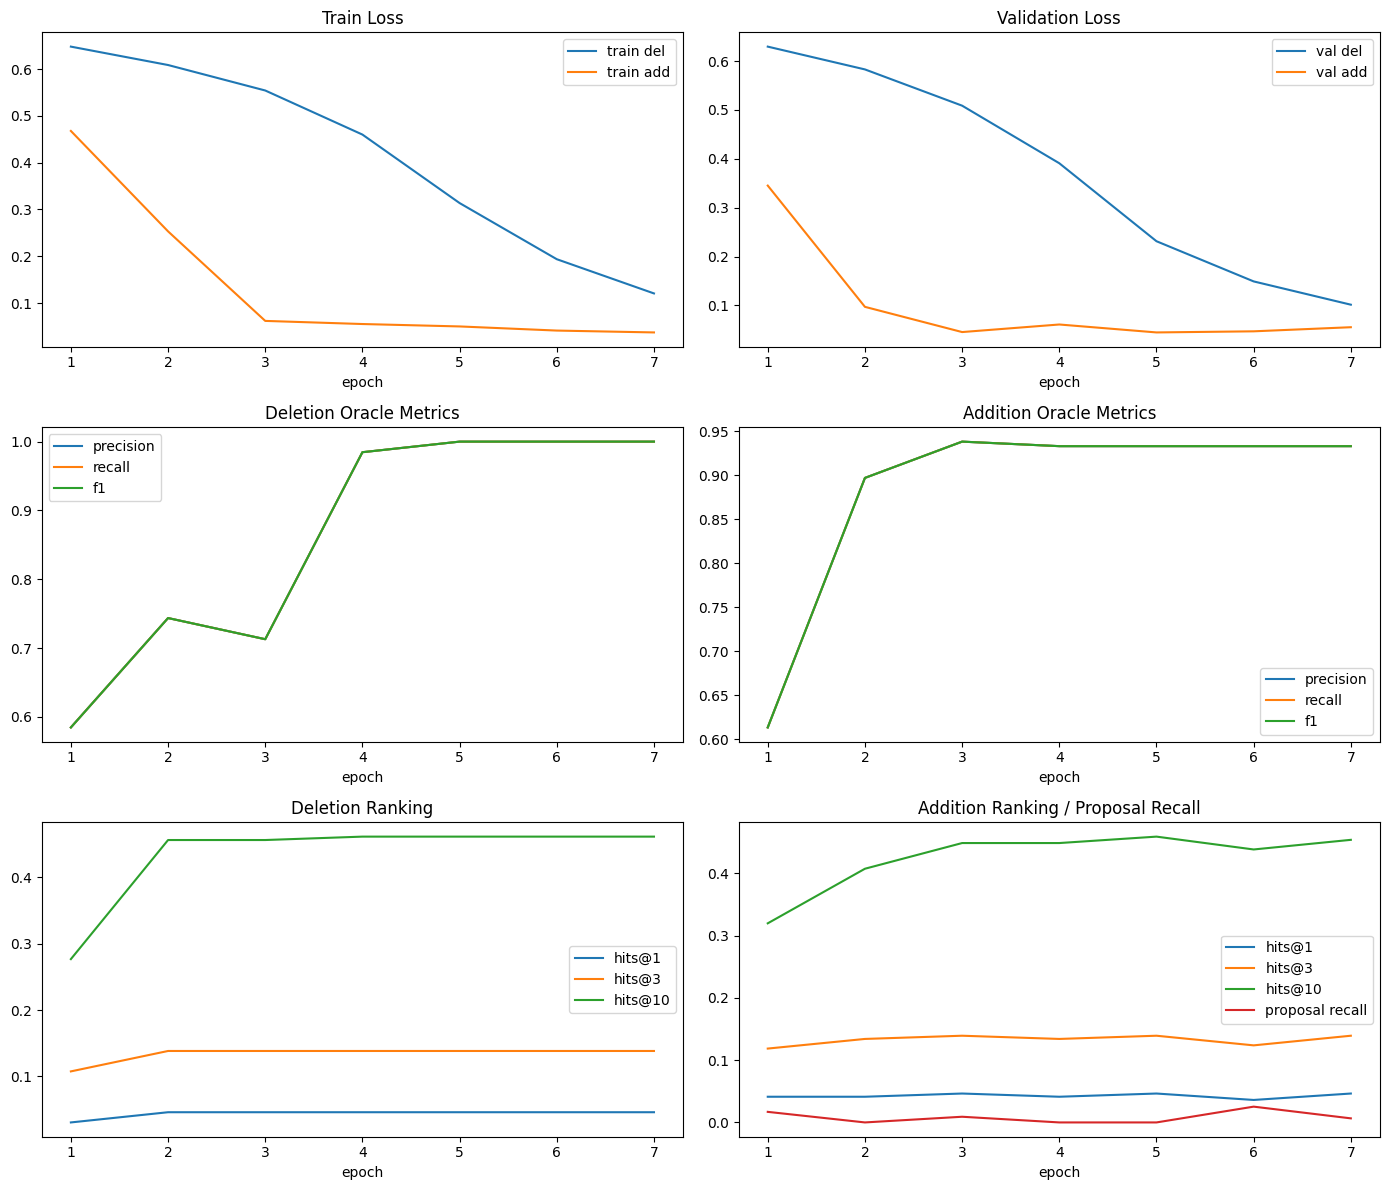

In [8]:
# Plot training curves only when at least one epoch has been recorded.
if len(history) > 0:
    # Extract the epoch indices once.
    epoch_ids = [row["epoch"] for row in history]

    # Build a 3x2 figure for the main learning curves.
    fig, axes = plt.subplots(3, 2, figsize=(14, 12))

    # Plot the training losses.
    axes[0, 0].plot(epoch_ids, [row["train_del_loss"] for row in history], label="train del")
    axes[0, 0].plot(epoch_ids, [row["train_add_loss"] for row in history], label="train add")
    axes[0, 0].set_title("Train Loss")
    axes[0, 0].set_xlabel("epoch")
    axes[0, 0].legend()

    # Plot the validation losses.
    axes[0, 1].plot(epoch_ids, [row["del_loss"] for row in history], label="val del")
    axes[0, 1].plot(epoch_ids, [row["add_loss"] for row in history], label="val add")
    axes[0, 1].set_title("Validation Loss")
    axes[0, 1].set_xlabel("epoch")
    axes[0, 1].legend()

    # Plot deletion precision / recall / F1.
    axes[1, 0].plot(epoch_ids, [row["del_precision"] for row in history], label="precision")
    axes[1, 0].plot(epoch_ids, [row["del_recall"] for row in history], label="recall")
    axes[1, 0].plot(epoch_ids, [row["del_f1"] for row in history], label="f1")
    axes[1, 0].set_title("Deletion Oracle Metrics")
    axes[1, 0].set_xlabel("epoch")
    axes[1, 0].legend()

    # Plot addition precision / recall / F1.
    axes[1, 1].plot(epoch_ids, [row["add_precision"] for row in history], label="precision")
    axes[1, 1].plot(epoch_ids, [row["add_recall"] for row in history], label="recall")
    axes[1, 1].plot(epoch_ids, [row["add_f1"] for row in history], label="f1")
    axes[1, 1].set_title("Addition Oracle Metrics")
    axes[1, 1].set_xlabel("epoch")
    axes[1, 1].legend()

    # Plot ranking hits for the deletion head.
    axes[2, 0].plot(epoch_ids, [row["del_hits@1"] for row in history], label="hits@1")
    axes[2, 0].plot(epoch_ids, [row["del_hits@3"] for row in history], label="hits@3")
    axes[2, 0].plot(epoch_ids, [row["del_hits@10"] for row in history], label="hits@10")
    axes[2, 0].set_title("Deletion Ranking")
    axes[2, 0].set_xlabel("epoch")
    axes[2, 0].legend()

    # Plot ranking hits and proposer recall for the addition head.
    axes[2, 1].plot(epoch_ids, [row["add_hits@1"] for row in history], label="hits@1")
    axes[2, 1].plot(epoch_ids, [row["add_hits@3"] for row in history], label="hits@3")
    axes[2, 1].plot(epoch_ids, [row["add_hits@10"] for row in history], label="hits@10")
    axes[2, 1].plot(epoch_ids, [row["add_proposal_recall"] for row in history], label="proposal recall")
    axes[2, 1].set_title("Addition Ranking / Proposal Recall")
    axes[2, 1].set_xlabel("epoch")
    axes[2, 1].legend()

    # Tighten the figure layout.
    plt.tight_layout()

    # Display the figure inline.
    plt.show()

rollout step 1: 10 nodes, 15 edges, +6 added, -1 removed, 9 survived, rt=[0.00, 5.00]
rollout step 2: 10 nodes, 15 edges, +4 added, -4 removed, 11 survived, rt=[0.00, 5.00]
rollout step 3: 10 nodes, 18 edges, +7 added, -4 removed, 11 survived, rt=[0.00, 5.00]
rollout step 4: 10 nodes, 18 edges, +7 added, -7 removed, 11 survived, rt=[0.00, 2.00]
rollout step 5: 10 nodes, 23 edges, +8 added, -3 removed, 15 survived, rt=[0.00, 3.00]


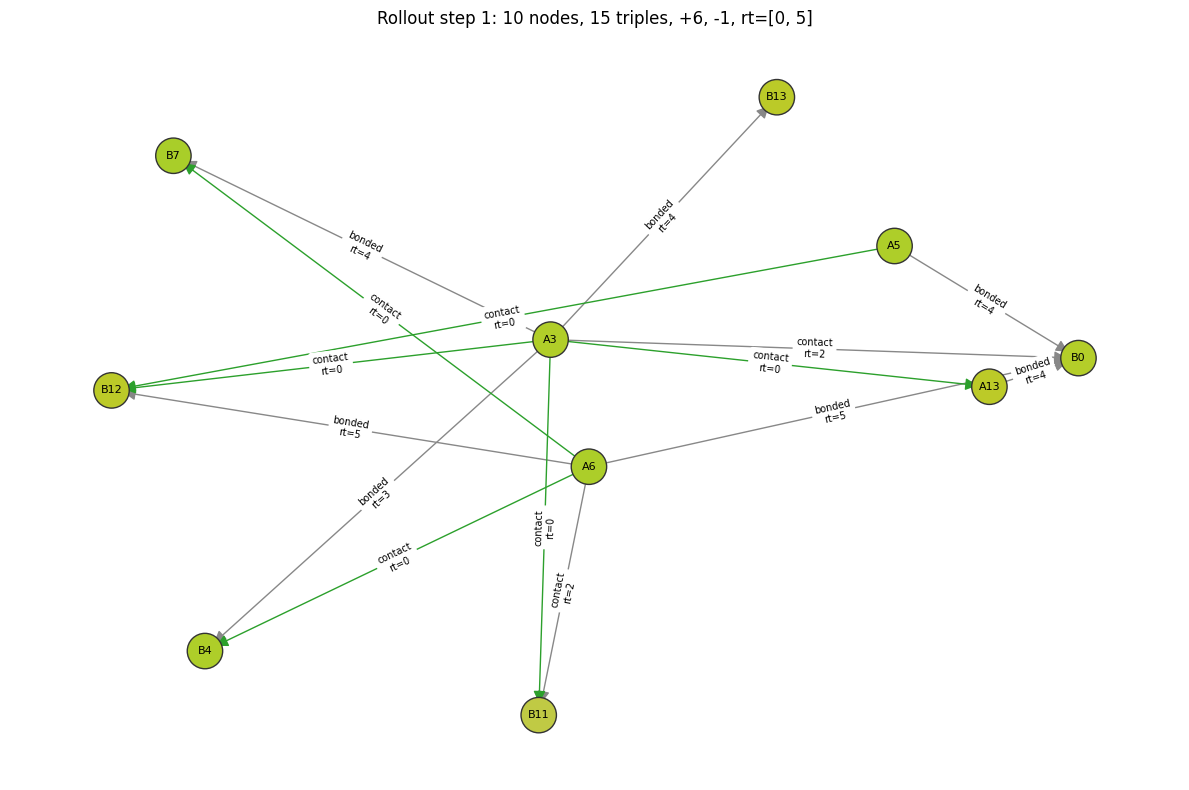

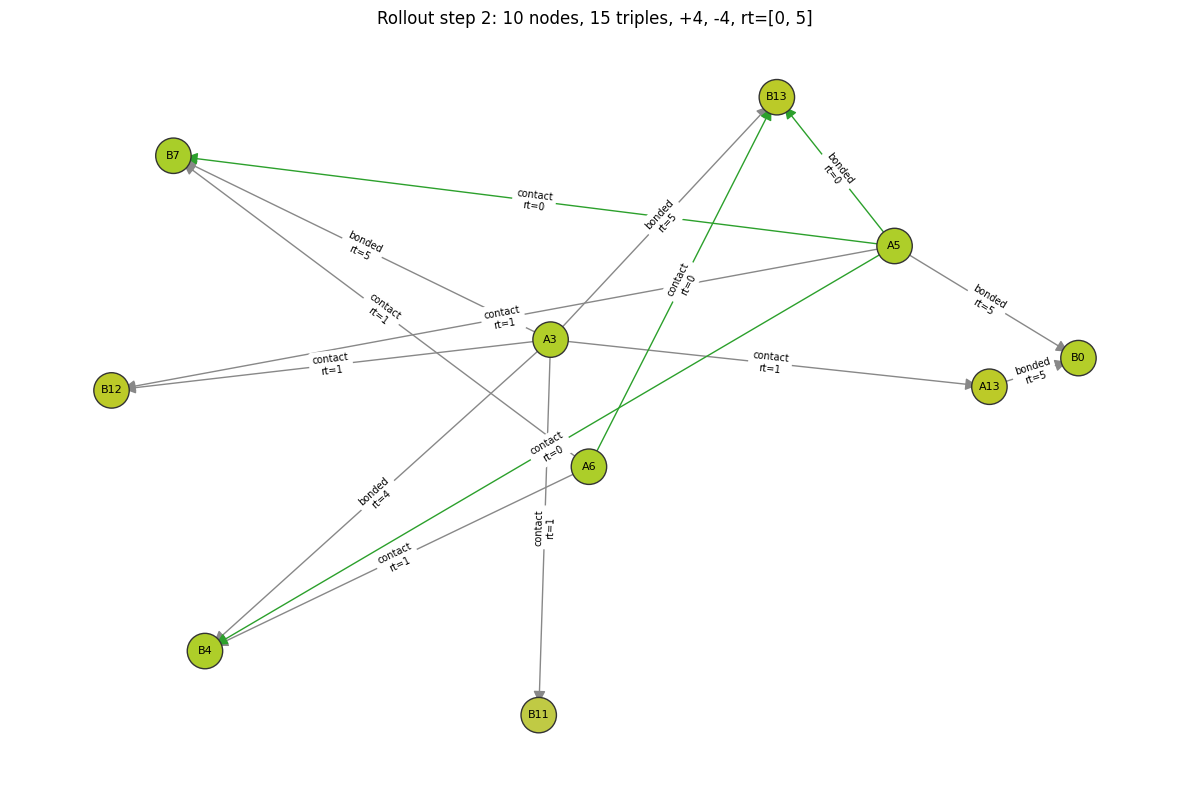

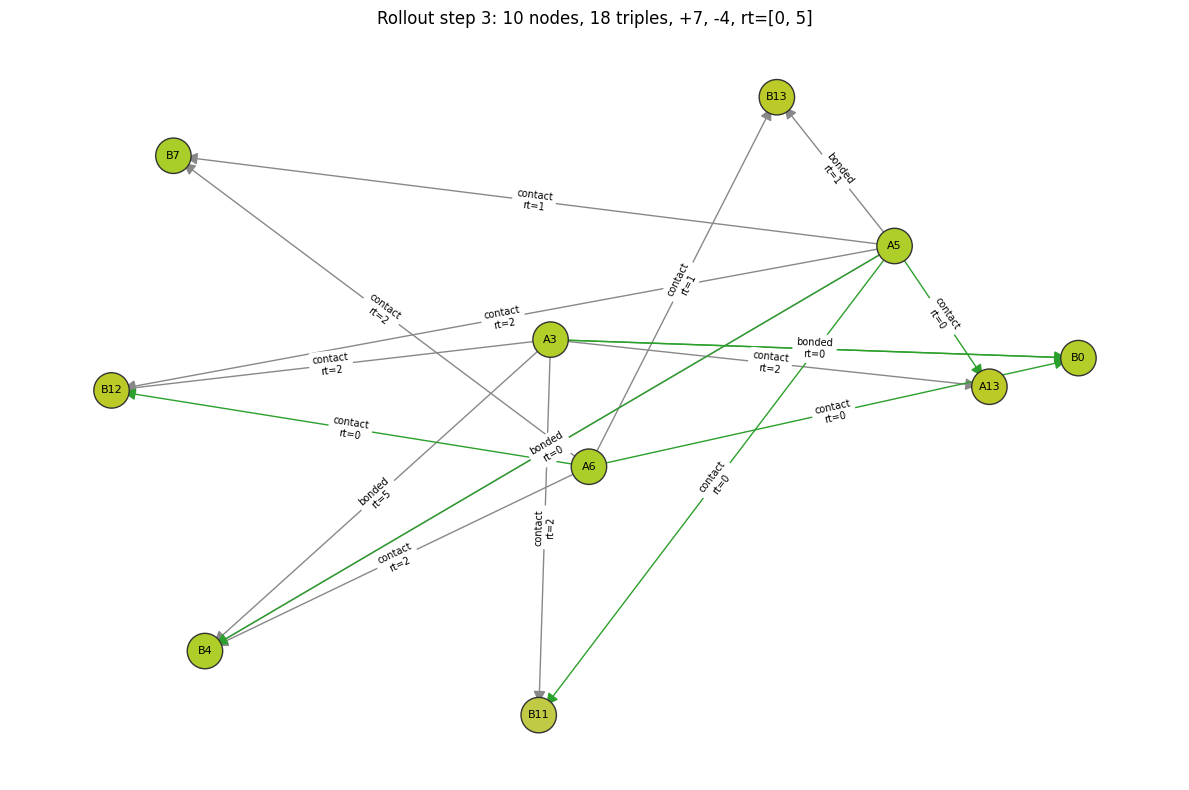

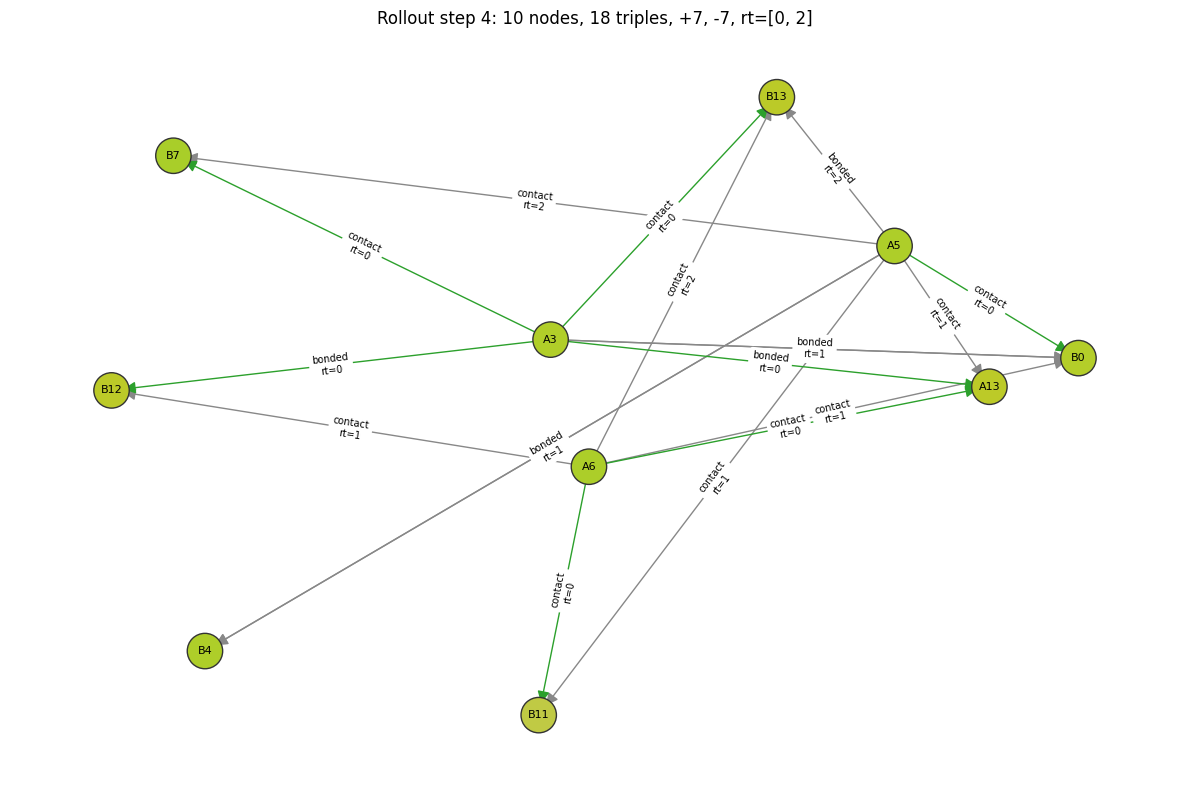

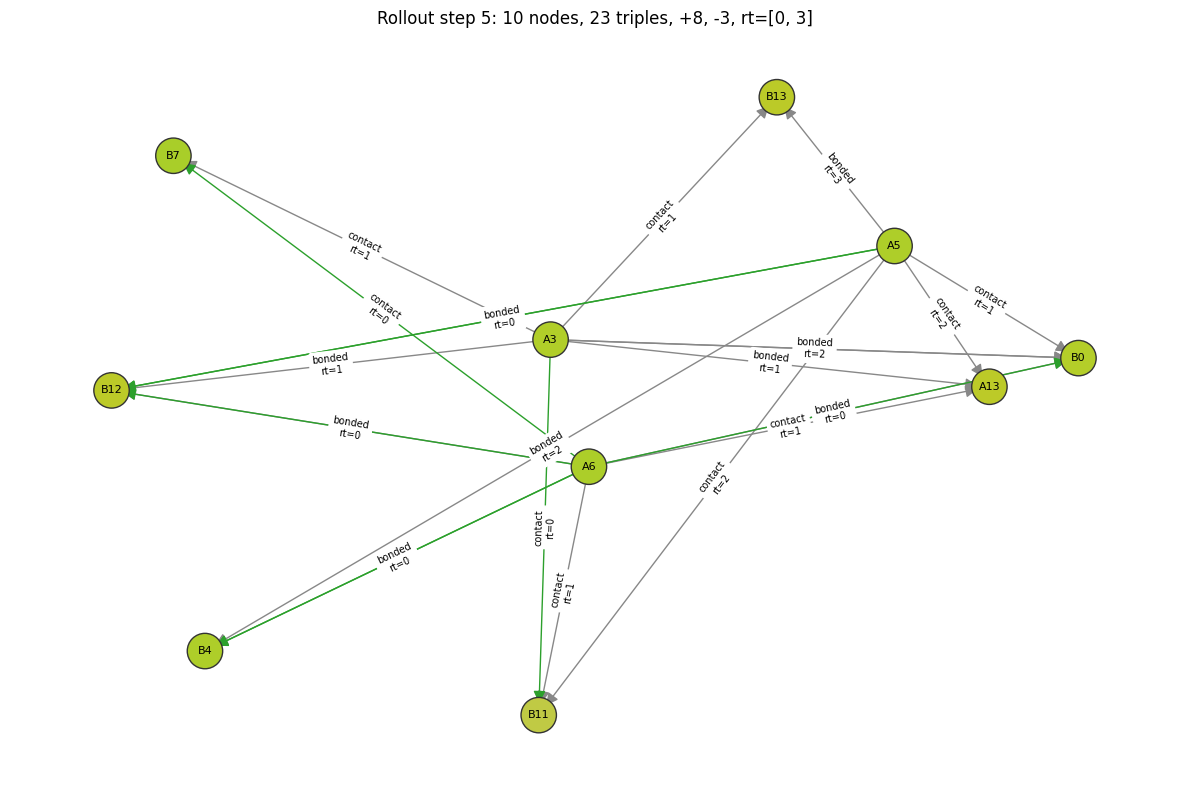

In [ ]:
# Sample a connected subgraph for qualitative rollout debugging.
def sample_connected_subgraph(
    edge_index: torch.Tensor,
    edge_type: torch.Tensor,
    num_nodes: int,
    seed: int = 7,
    edge_relative_time: Optional[torch.Tensor] = None,
):
    # Return the original graph immediately when it has no edges.
    if edge_index.size(1) == 0:
        if edge_relative_time is None:
            return edge_index, edge_type
        return edge_index, edge_type, edge_relative_time

    # Convert the edge endpoints into Python lists.
    src_list = edge_index[0].tolist()
    dst_list = edge_index[1].tolist()

    # Count the degree of every node that appears in the graph.
    all_nodes, counts = edge_index.flatten().unique(return_counts=True)

    # Return the full graph when it is already small enough.
    if all_nodes.numel() <= num_nodes:
        if edge_relative_time is None:
            return edge_index, edge_type
        return edge_index, edge_type, edge_relative_time

    # Build an undirected neighbor table for BFS.
    neighbors = {int(node): [] for node in all_nodes.tolist()}
    for src, dst in zip(src_list, dst_list):
        neighbors[int(src)].append(int(dst))
        neighbors[int(dst)].append(int(src))

    # Pick one random high-degree seed node for the BFS.
    rng = random.Random(seed)
    topk = min(20, all_nodes.numel())
    top_indices = counts.topk(topk).indices.tolist()
    seed_node = int(all_nodes[top_indices[rng.randint(0, topk - 1)]].item())

    # Initialize the BFS frontier and visited set.
    visited = {seed_node}
    queue = deque([seed_node])

    # Expand until the requested number of nodes is collected.
    while len(queue) > 0 and len(visited) < num_nodes:
        node = queue.popleft()
        for neighbor in neighbors[node]:
            if neighbor not in visited:
                visited.add(neighbor)
                queue.append(neighbor)
            if len(visited) >= num_nodes:
                break

    # Keep only edges whose endpoints both lie inside the visited set.
    mask = torch.tensor([(src in visited and dst in visited) for src, dst in zip(src_list, dst_list)], dtype=torch.bool)

    # Slice the induced subgraph tensors.
    sampled_edge_index = edge_index[:, mask]
    sampled_edge_type = edge_type[mask]

    # Keep the aligned relative-time tensor when one was provided.
    if edge_relative_time is None:
        return sampled_edge_index, sampled_edge_type

    # Slice the matching relative-time values with the same mask.
    sampled_edge_relative_time = edge_relative_time[mask]

    # Return the induced subgraph together with its edge ages.
    return sampled_edge_index, sampled_edge_type, sampled_edge_relative_time


# Turn one node label into a stable hex color using smooth lexical features.
def label_to_hex_color(label: str) -> str:
    # Normalize the label so nearby strings produce nearby feature values.
    normalized = "".join(ch.lower() for ch in str(label) if ch.isalnum())

    # Fall back to a small default token when the label is empty after normalization.
    if len(normalized) == 0:
        normalized = "node"

    # Convert the characters into numeric codes once.
    char_codes = [ord(ch) for ch in normalized]

    # Compute a position-aware mean so small text edits only shift the hue a bit.
    weighted_sum = sum((idx + 1) * code for idx, code in enumerate(char_codes))
    weight_total = sum(range(1, len(char_codes) + 1))
    weighted_mean = weighted_sum / max(weight_total, 1)

    # Mix in the first and last characters to separate labels with the same interior text.
    boundary_mean = 0.6 * char_codes[0] + 0.4 * char_codes[-1]

    # Measure how diverse the characters are so repetitive labels are a bit less saturated.
    unique_ratio = len(set(normalized)) / len(normalized)

    # Measure how digit-heavy the label is so numeric suffixes affect brightness smoothly.
    digit_ratio = sum(ch.isdigit() for ch in normalized) / len(normalized)

    # Map the smooth lexical statistics into an HSV hue in [0, 1].
    hue = ((0.65 * weighted_mean) + (0.35 * boundary_mean)) % 360.0 / 360.0

    # Keep saturation in a readable range while still reflecting label diversity.
    saturation = min(0.82, 0.38 + 0.42 * unique_ratio)

    # Keep the value channel bright enough for black node labels.
    value = min(0.92, 0.76 + 0.10 * (1.0 - digit_ratio))

    # Convert the HSV triplet into RGB floats.
    red, green, blue = colorsys.hsv_to_rgb(hue, saturation, value)

    # Return the RGB triplet as a CSS-style hex string.
    return f"#{int(red * 255):02x}{int(green * 255):02x}{int(blue * 255):02x}"


# Format one relative-time value so edge labels stay compact.
def format_relative_time(value: float) -> str:
    # Round first so tiny floating-point noise does not leak into the label.
    rounded_value = round(float(value), 2)

    # Show integer-looking values without a decimal suffix.
    if rounded_value.is_integer():
        return str(int(rounded_value))

    # Keep up to two decimals for non-integer values.
    return f"{rounded_value:.2f}".rstrip("0").rstrip(".")


# Visualize one rollout step using a fixed node layout when available.
def visualize_rollout_step(
    step_result,
    id_to_entity,
    id_to_rel,
    step_num: int,
    pos=None,
):
    # Create a directed multigraph so parallel KG edges keep separate labels.
    graph = nx.MultiDiGraph()

    # Read the edge-age map when rollout stored one for this step.
    edge_age_map = step_result.get("edge_age_map", {})

    # Prefer the aligned tensor representation when rollout stored it directly.
    if "edge_index" in step_result and "edge_type" in step_result and "edge_relative_time" in step_result:
        plotted_triples = snapshot_to_triples(step_result["edge_index"], step_result["edge_type"])
        plotted_relative_times = [float(value) for value in step_result["edge_relative_time"].tolist()]
    else:
        plotted_triples = sorted(step_result["edge_set"])
        plotted_relative_times = [float(edge_age_map.get(triple, 0.0)) for triple in plotted_triples]

    # Add every triple in the displayed graph.
    for (src_id, rel_id, dst_id), relative_time in zip(plotted_triples, plotted_relative_times):
        src_label = id_to_entity.get(src_id, str(src_id))
        dst_label = id_to_entity.get(dst_id, str(dst_id))
        rel_label = id_to_rel.get(rel_id, str(rel_id))
        is_new = (src_id, rel_id, dst_id) in step_result["added"]
        edge_key = f"{src_id}|{rel_id}|{dst_id}"
        graph.add_edge(
            src_label,
            dst_label,
            key=edge_key,
            relation=f"{rel_label}\nrt={format_relative_time(relative_time)}",
            relative_time=float(relative_time),
            is_new=is_new,
        )

    # Reuse the provided layout when available so node motion does not hide edge changes.
    if pos is None:
        draw_pos = nx.spring_layout(graph, seed=42)
    else:
        centroid = np.mean(list(pos.values()), axis=0) if len(pos) > 0 else np.array([0.0, 0.0])
        draw_pos = {node: pos.get(node, centroid) for node in graph.nodes()}

    # Split edges into unchanged and newly-added groups.
    unchanged_edges = [(u, v, key) for u, v, key, data in graph.edges(keys=True, data=True) if not data["is_new"]]
    added_edges = [(u, v, key) for u, v, key, data in graph.edges(keys=True, data=True) if data["is_new"]]

    # Collect one age summary so it is obvious whether rollout aging is working.
    displayed_relative_times = [data["relative_time"] for _, _, _, data in graph.edges(keys=True, data=True)]
    min_relative_time = min(displayed_relative_times) if len(displayed_relative_times) > 0 else 0.0
    max_relative_time = max(displayed_relative_times) if len(displayed_relative_times) > 0 else 0.0

    # Create the figure.
    fig, ax = plt.subplots(figsize=(12, 8))

    # Build one stable node color per node label.
    node_colors = [label_to_hex_color(str(node)) for node in graph.nodes()]

    # Draw nodes and labels first.
    nx.draw_networkx_nodes(
        graph,
        draw_pos,
        node_size=650,
        node_color=node_colors,
        edgecolors="#333333",
        linewidths=1.0,
        ax=ax,
    )
    nx.draw_networkx_labels(graph, draw_pos, font_size=8, ax=ax)

    # Draw unchanged edges in gray.
    nx.draw_networkx_edges(
        graph,
        draw_pos,
        edgelist=unchanged_edges,
        edge_color="#888888",
        arrows=True,
        arrowstyle="-|>",
        arrowsize=18,
        ax=ax,
    )

    # Draw added edges in green.
    nx.draw_networkx_edges(
        graph,
        draw_pos,
        edgelist=added_edges,
        edge_color="#2ca02c",
        arrows=True,
        arrowstyle="-|>",
        arrowsize=18,
        ax=ax,
    )

    # Draw relation labels, including one label per parallel edge in the multigraph.
    nx.draw_networkx_edge_labels(
        graph,
        draw_pos,
        edge_labels={(u, v, key): data["relation"] for u, v, key, data in graph.edges(keys=True, data=True)},
        font_size=7,
        ax=ax,
    )

    # Add a title that summarizes the step.
    ax.set_title(
        f"Rollout step {step_num}: "
        f"{graph.number_of_nodes()} nodes, "
        f"{len(step_result['edge_set'])} triples, "
        f"+{len(step_result['added'])}, "
        f"-{len(step_result['removed'])}, "
        f"rt=[{format_relative_time(min_relative_time)}, {format_relative_time(max_relative_time)}]"
    )

    # Hide the axes.
    ax.axis("off")

    # Tighten the figure layout.
    plt.tight_layout()

    # Display the figure inline.
    ipy_display(fig)

    # Close the figure to avoid duplicate notebook output.
    plt.close(fig)


# Example rollout usage.
#
# Uncomment the block below after training if you want a quick qualitative check.
#
start_snapshot = dataset[min(TRAIN_END, len(dataset) - 1)]
sub_edge_index, sub_edge_type, sub_edge_relative_time = sample_connected_subgraph(
    start_snapshot.edge_index,
    start_snapshot.edge_type,
    num_nodes=10,
    seed=SEED,
    edge_relative_time=start_snapshot.edge_relative_time,
)
rollout_steps = model.rollout(
    x_global=dataset.x_global,
    edge_index=sub_edge_index,
    edge_type=sub_edge_type,
    edge_relative_time=sub_edge_relative_time,
    num_steps=5,
    device=DEVICE,
    history_len=HISTORY_LEN,
    proposal_target_count=PROPOSAL_TARGET_COUNT,
    sampling="threshold",
    add_threshold=0.7,
    del_threshold=0.7,
)
initial_graph = nx.DiGraph()
for src_id, rel_id, dst_id in snapshot_to_triples(sub_edge_index, sub_edge_type):
    initial_graph.add_edge(
        dataset.id_to_entity.get(src_id, str(src_id)),
        dataset.id_to_entity.get(dst_id, str(dst_id)),
    )
fixed_pos = nx.spring_layout(initial_graph, seed=42)
for step_idx, step_result in enumerate(rollout_steps, start=1):
    visualize_rollout_step(
        step_result=step_result,
        id_to_entity=dataset.id_to_entity,
        id_to_rel=dataset.id_to_rel,
        step_num=step_idx,
        pos=fixed_pos,
    )